In [6]:
import polars as pl
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import plotly.express as px
import os
import sys
import datetime as dt

In [7]:
sys.path.insert(1, '..')
from SepsisPkg.config import SEPSIS_CONFIG

# Dataset v 1.2

In [8]:
# Constants
RAW_DATA_PATH = "../data/raw_data_new"
files = sorted(os.listdir(RAW_DATA_PATH))

In [9]:
BASELINE_COLS = [
    'Baseline_SBP',
	'Baseline_DBP',
	'Baseline_RespiratoryRate',
	'Baseline_PulseRate',
	'Baseline_Creatinine',
	'Baseline_Bilirubin',
	'Baseline_Platelets',
	'Baseline_WBC',
	'Baseline_BUN',
	'Baseline_LVEF'
]

In [10]:
def cast_datetime_cols(
	lf: pl.LazyFrame,
	cols = ['Pt_Arrival', 'Event_DateTime', 'Admit_Time']
):
	schema = lf.collect_schema()
	for c in cols:
		if schema[c] in [pl.Utf8, pl.String]:
			lf = lf.with_columns(
			pl.col(c).str.strptime(pl.Datetime, format="%Y-%m-%d %H:%M:%S%.f")
		)
	return lf

In [11]:
lf_list = []
meas_value_char = []
meas_value_rate = []

lf_baseline = None
for idx, f in enumerate(files):
    if f == 'SOFA Scores - 1.13.26.csv': continue
    f_path = os.path.join(RAW_DATA_PATH, f)
    lf_f = pl.scan_csv(
        f_path,
        null_values=['null', 'NULL', 'Null', "None"],
        infer_schema_length=int(1e7)
    )

    schema = lf_f.collect_schema()
    if 'Event_Datetime' in schema.names():
        print("renamed")
        lf_f = lf_f.rename(
            {'Event_Datetime': 'Event_DateTime'}
        )
    if 'MEAS_VALUE_RATE' in schema.names():
        meas_value_rate.append((lf_f.filter(
            pl.col("MEAS_VALUE_RATE").is_not_null()
            # pl.col("MEAS_VALUE_RATE").is_not_nan()
        ).select("PAT_ENC_CSN_ID", "Event_DateTime", "EVENT_NAME", "MEAS_VALUE_RATE").collect(), f))
        lf_f = lf_f.drop("MEAS_VALUE_RATE")

    if 'MEAS_VALUE_CHAR' in schema.names():
        meas_value_char.append((lf_f.filter(
            pl.col("MEAS_VALUE_CHAR").is_not_null()
            # pl.col("MEAS_VALUE_CHAR").is_not_nan()
        ).select("PAT_ENC_CSN_ID", "Event_DateTime", "EVENT_NAME", "MEAS_VALUE_CHAR").collect(), f))
        lf_f = lf_f.drop("MEAS_VALUE_CHAR")
    
    if  'MEAS_VALUE' in schema.names() and schema['MEAS_VALUE'] not in [pl.Utf8, pl.String]:
        lf_f = lf_f.with_columns(
           pl.col("MEAS_VALUE").cast(pl.Utf8)
        )
    if 'Before_Admit_YN' in schema.names():
        print(f"Dropping Before_Admit_YN for file {f}\n")
        lf_f = lf_f.drop("Before_Admit_YN")

    if 'Event_ID' in schema.names():
        print(f"Dropping Event_ID for file {f}\n")
        lf_f = lf_f.drop("Event_ID")
    
    if f == 'Encounter Table with Baseline Values - Dec 2024 - Nov 2025.csv':
        lf_baseline = lf_f
        continue
    
    lf_list.append(lf_f)

renamed
Dropping Before_Admit_YN for file Flowsheet Character and BP - Dec 2024 - Nov 2025.csv

Dropping Event_ID for file Flowsheet Character and BP - Dec 2024 - Nov 2025.csv

renamed
Dropping Before_Admit_YN for file Flowsheet Value - Dec 2024 - Nov 2025.csv

Dropping Event_ID for file Flowsheet Value - Dec 2024 - Nov 2025.csv

Dropping Before_Admit_YN for file LVEF, Proc Orders, Dx - Dec 2024 - Nov 2025.csv

Dropping Event_ID for file LVEF, Proc Orders, Dx - Dec 2024 - Nov 2025.csv

Dropping Before_Admit_YN for file Lab Results - Dec 2024 - Nov 2025.csv

Dropping Event_ID for file Lab Results - Dec 2024 - Nov 2025.csv

Dropping Before_Admit_YN for file Med Orders and Admin - Dec 2024 - Nov 2025.csv

Dropping Event_ID for file Med Orders and Admin - Dec 2024 - Nov 2025.csv



In [12]:
temp_schema = None
default_list = []
for idx, lf in enumerate(lf_list):
    schema = lf.collect_schema()
    if temp_schema is None:
        temp_schema = schema
    else:
        for col, dtype in schema.items():
            if temp_schema[col] != dtype:
                print(f"There is a mismatch between in {col}: {dtype} != {temp_schema[col]} -- {idx}")

In [13]:
lf_all = pl.concat(
    lf_list
)

In [14]:
# if schema['Pt_Arrival'] in [pl.Utf8, pl.String]:
#     lf_all = lf_all.with_columns(
#     pl.col("Pt_Arrival").str.strptime(pl.Datetime, format="%Y-%m-%d %H:%M:%S%.f")
#     )
# if schema['Admit_Time'] in [pl.Utf8, pl.String]:
#     lf_all = lf_all.with_columns(
#     pl.col("Admit_Time").str.strptime(pl.Datetime, format="%Y-%m-%d %H:%M:%S%.f")
#     )
# if schema['Event_DateTime'] in [pl.Utf8, pl.String]:
#     lf_all = lf_all.with_columns(
#     pl.col("Event_DateTime").str.strptime(pl.Datetime, format="%Y-%m-%d %H:%M:%S%.f")
#     )

# lf_baseline = cast_datetime_cols(lf_baseline, ['Pt_Arrival', 'Admit_Time'])
lf_all = cast_datetime_cols(lf_all, ['Pt_Arrival', 'Event_DateTime', 'Admit_Time'])
lf_all = lf_all.with_columns(
    event_full_name = (pl.col("Type")+"_"+pl.col("EVENT_NAME")+"_"+pl.col("Event_Grouper")).str.to_lowercase()
).sort(by=['PAT_ENC_CSN_ID', 'Event_DateTime'])

In [15]:

included_cultures = [
    # Blood cultures
    "CULTURE BLOOD",
    "CULTURE BLOOD ID MALDI - AEROBIC",
    "CULTURE BLOOD ID MALDI - ANAEROBIC",
    "CULTURE BLOOD ID MALDI-AEROBIC",
    "CULTURE BLOOD ID MALDI-ANAEROBIC",
    "CULTURE BLOOD ID NAAT- AEROBIC",
    "CULTURE BLOOD ID NAAT- ANAEROBIC",

    # Fungal and mycobacterial blood cultures
    "FUNGAL BLOOD CULTURE",
    "FUNGAL CULTURE, BLOOD",
    "MYCOBACTERIAL CULTURE, BLOOD",
    "AFB BLOOD CULTURE",

    # Sterile site cultures
    "CULTURE STERILE SITE",
    "CULTURE CSF + GRAM STAIN",
    "CULTURE ANAEROBIC",
    "CULTURE AEROBIC + ANAEROBIC + GRAM STAIN",
    "CULTURE AEROBIC AND ANAEROBIC RESULT",

    # Device-related sterile cultures
    "CULTURE CATH TIP",
    "CULTURE URINE",
    "CULTURE SPUTUM + SCREENING SMEAR",
    "CULTURE RESPIRATORY (NON SPUTUM) + STAIN",
]

excluded_cultures = [
    # BCID organism identifications (results, not orders)
    "COAGULASE-NEGATIVE STAPHYLOCOCCUS BCID",
    "KLEBSIELLA AEROGENES GROUP BCID",
    "KLEBSIELLA PNEUMONIAE GROUP BCID",
    "KLEBSIELLA OXYTOCA BCID",
    "ESCHERICHIA COLI BCID",
    "SERRATIA MARCESCENS BCID",
    "ACINETOBACTER CALCOACETICUS-BAUMANNII COMPLEX BCID",
    "STENOTROPHOMONAS MALTOPHILIA BCID",
    "ENTEROBACTER CLOACAE COMPLEX BCID",
    "STAPHYLOCOCCUS SP BCID",
    "STAPHYLOCOCCUS LUGDUNENSIS BCID",
    "STAPHYLOCOCCUS AUREUS BCID",
    "STREPTOCOCCUS SP BCID",
    "STREPTOCOCCUS PNEUMONIAE BCID",
    "GROUP B STREPTOCOCCUS BCID",
    "ENTEROCOCCUS FAECALIS BCID",
    "ENTEROCOCCUS FAECIUM BCID",
    "PROTEUS SP BCID",
    "HAEMOPHILUS INFLUENZAE BCID",
    "PSEUDOMONAS AERUGINOSA BCID",
    "SALMONELLA SP BCID",
    "BACTEROIDES FRAGILIS BCID",
    "LISTERIA MONOCYTOGENES BCID",
    "ENTEROBACTERALES",

    # Resistance and gene markers
    "CTX-M GENE BCID",
    "OXA GENE BCID",
    "NDM GENE",
    "VANAB GENE BCID",
    "MEC A/C AND MREJ (MRSA) GENE",

    # Fungal or organism species results
    "CANDIDA ALBICANS",
    "CANDIDA KRUSEI",
    "CANDIDA PARAPSILOSIS",
    "CANDIDA TROPICALIS",
    "NAKASEOMYCES CANDIDA GLABRATA",
    "CANDIDA AURIS",
    "CRYPTOCOCCUS NEOFORMANS/GATTII",

    # Stains, smears, and microscopy
    "GRAM STAIN",
    "GRAM ST",
    "AFB SMEAR",
    "MODIFIED ACID FAST STAIN",
    "FUNGAL SMEAR",

    # Status, metadata, and generic rows
    "BCID NAAT INTERPRETATION",
    "CULTURE STATUS",
    "RESULT",
    "ISOLATE 1",
    "CULTURE SOURCE",
    "CULTURE",
]

more_refined_included_cultures = [
    # Primary 
    "CULTURE BLOOD",
    "FUNGAL BLOOD CULTURE",
    "FUNGAL CULTURE, BLOOD",
    "MYCOBACTERIAL CULTURE, BLOOD",
    "AFB BLOOD CULTURE",
    "CULTURE STERILE SITE",
    "CULTURE CSF + GRAM STAIN",
    "CULTURE ANAEROBIC",
    "CULTURE AEROBIC + ANAEROBIC + GRAM STAIN",
    "CULTURE AEROBIC AND ANAEROBIC RESULT",
    "CULTURE CATH TIP",

    # Secondary
    "CULTURE URINE",
    "CULTURE SPUTUM + SCREENING SMEAR",
    "CULTURE RESPIRATORY (NON SPUTUM) + STAIN",
]

included_cultures_lowercase = list(map(lambda x: x.lower(), included_cultures))

def get_AI_based_filter():
    expr_antibiotic_filter = (
    (pl.col("Event_Grouper") == 'Antibiotics')&
    ~(pl.col("EVENT_NAME").str.to_lowercase().str.contains(r"topical|oral|otic|lock|intravitreal|irrigation"))
    )
    expr_culture_filter = (
        pl.col("event_full_name").str.ends_with("body fluid cultures") & 
        pl.col("event_full_name").str.contains(fr"{'|'.join(included_cultures_lowercase)}") 
        
    )
    return expr_antibiotic_filter, expr_culture_filter

def get_all_antibiotic_cultures():
    expr_antibiotic_filter = (
        pl.col("event_full_name").str.ends_with("antibiotics") 
    )
    expr_culture_filter = (
        pl.col("event_full_name").str.ends_with("body fluid cultures") 
    )
    return expr_antibiotic_filter, expr_culture_filter

def get_expressions(with_AI_filter=True):
    if with_AI_filter:
        return get_AI_based_filter()
    else:
        return get_all_antibiotic_cultures()

In [16]:
df_all = lf_all.collect()

In [17]:
expr_anti, expr_culture = get_expressions(False)
expr_anti_ai, expr_culture_ai = get_expressions(True)


In [18]:
# Using all values of antibiotics and cultures
df_antibiotic_all = df_all.filter(
    expr_anti
).select(
    "PAT_ENC_CSN_ID",
    pl.col("Event_DateTime").alias("ABX_time"),
    pl.col("event_full_name").alias("ABX")
)

df_culture_all = df_all.filter(
   expr_culture 
).select(
    "PAT_ENC_CSN_ID",
    pl.col("Event_DateTime").alias("culture_time"),
    pl.col("event_full_name").alias("culture_name")
)

df_suspected_backward = df_antibiotic_all.join_asof(
    df_culture_all,
    left_on='ABX_time',
    right_on='culture_time',
    strategy="backward",
    by="PAT_ENC_CSN_ID",
    tolerance="24h"
).filter(pl.col("culture_time").is_not_null())

df_suspected_forward = df_antibiotic_all.join_asof(
    df_culture_all,
    left_on='ABX_time',
    right_on='culture_time',
    strategy="forward",
    by="PAT_ENC_CSN_ID",
    tolerance="72h"
).filter(pl.col("culture_time").is_not_null())

df_f_b = pl.concat([df_suspected_backward, df_suspected_forward])

/tmp/ipykernel_1622380/228405345.py:18: UserWarning: Sortedness of columns cannot be checked when 'by' groups provided
  df_suspected_backward = df_antibiotic_all.join_asof(
/tmp/ipykernel_1622380/228405345.py:27: UserWarning: Sortedness of columns cannot be checked when 'by' groups provided
  df_suspected_forward = df_antibiotic_all.join_asof(


In [19]:
# Using AI filtered antibiotic and cultures
df_antibiotic_all = df_all.filter(
    expr_anti_ai
).select(
    "PAT_ENC_CSN_ID",
    pl.col("Event_DateTime").alias("ABX_time"),
    pl.col("event_full_name").alias("ABX")
)

df_culture_all = df_all.filter(
   expr_culture_ai 
).select(
    "PAT_ENC_CSN_ID",
    pl.col("Event_DateTime").alias("culture_time"),
    pl.col("event_full_name").alias("culture_name")
)

df_suspected_backward = df_antibiotic_all.join_asof(
    df_culture_all,
    left_on='ABX_time',
    right_on='culture_time',
    strategy="backward",
    by="PAT_ENC_CSN_ID",
    tolerance="24h"
).filter(pl.col("culture_time").is_not_null())

df_suspected_forward = df_antibiotic_all.join_asof(
    df_culture_all,
    left_on='ABX_time',
    right_on='culture_time',
    strategy="forward",
    by="PAT_ENC_CSN_ID",
    tolerance="72h"
).filter(pl.col("culture_time").is_not_null())

df_f_b_ai = pl.concat([df_suspected_backward, df_suspected_forward])

/tmp/ipykernel_1622380/3989602184.py:18: UserWarning: Sortedness of columns cannot be checked when 'by' groups provided
  df_suspected_backward = df_antibiotic_all.join_asof(
/tmp/ipykernel_1622380/3989602184.py:27: UserWarning: Sortedness of columns cannot be checked when 'by' groups provided
  df_suspected_forward = df_antibiotic_all.join_asof(


In [23]:
# NUM encounters with no sepsis suspicion after including all antibiotics and cultures
len(set(df_all['PAT_ENC_CSN_ID'].unique()) - set(df_f_b['PAT_ENC_CSN_ID'].unique()))

99

In [25]:
df_missed = df_all.filter(pl.col("PAT_ENC_CSN_ID").is_in(set(df_all['PAT_ENC_CSN_ID'].unique()) - set(df_f_b['PAT_ENC_CSN_ID'].unique())))

In [31]:
miss_sep = df_missed.group_by("PAT_ENC_CSN_ID").agg(pl.col("Sepsis_Category").last())['Sepsis_Category'].value_counts().sort(by='Sepsis_Category')

In [32]:
all_sep =df_all.group_by("PAT_ENC_CSN_ID").agg(pl.col("Sepsis_Category").last())['Sepsis_Category'].value_counts().sort(by='Sepsis_Category')

In [38]:
miss_sep.join(all_sep, how='right', on='Sepsis_Category').with_columns(
    perc = pl.col("count")/pl.col("count_right")
).fill_null(0).select(
    "Sepsis_Category",
    "count",
    "count_right",
    "perc"
).rename({
    "count": "missed_count",
    "count_right": "total_count"
})

Sepsis_Category,missed_count,total_count,perc
str,u64,u64,f64
"""NPOA-1""",7,212,0.033019
"""NPOA-2""",0,43,0.0
"""NPOA-3""",1,312,0.003205
"""POA-1""",64,1819,0.035184
"""POA-2""",12,739,0.016238
"""POA-3""",8,780,0.010256
"""UPOA-1""",7,77,0.090909
"""UPOA-2""",0,7,0.0
"""UPOA-3""",0,1,0.0


In [39]:
df_missed.columns

['PAT_ENC_CSN_ID',
 'PAT_MRN_ID',
 'PAT_ID',
 'Ethnicity',
 'FirstRace',
 'Sex',
 'Coverage_Financial_Class_Grouper',
 'Pt_Arrival',
 'Admit_Time',
 'DateAdmitKey',
 'Patient_Age',
 'Chief_Complaint',
 'Chief_Complaint_All',
 'Baseline_SBP',
 'Baseline_LVEF',
 'Admitted_From_ED',
 'LOS_Days',
 'Hours_in_ED',
 'Event_DateTime',
 'Type',
 'EVENT_NAME',
 'Event_Grouper',
 'Result_Flag',
 'MEAS_VALUE',
 'Sepsis_Category',
 'FLAG_DEATH_CLARITY',
 'event_full_name']

In [42]:
df_missed.group_by("PAT_ENC_CSN_ID").agg(pl.col("FLAG_DEATH_CLARITY").last())["FLAG_DEATH_CLARITY"].value_counts()

FLAG_DEATH_CLARITY,count
i64,u64
1,1
0,98


In [43]:
df_missed.filter(pl.col("FLAG_DEATH_CLARITY")==1)['PAT_ENC_CSN_ID'].unique()

PAT_ENC_CSN_ID
i64
739029591


In [78]:
len(df_f_b)-len(df_f_b_ai)

146923

In [83]:
np.random.choice(list(set(df_f_b['PAT_ENC_CSN_ID'].unique())-set(df_f_b_ai['PAT_ENC_CSN_ID'].unique())), size=10, replace=False).tolist()

[734834356,
 722560430,
 721536295,
 722456427,
 739109618,
 717740648,
 732249215,
 717479919,
 715683762,
 720189281]

In [ ]:
expr_antibiotic_filter = (
    (pl.col("Event_Grouper") == 'Antibiotics')&
    ~(pl.col("EVENT_NAME").str.to_lowercase().str.contains(r"topical|oral|otic|lock|intravitreal|irrigation"))
    )

expr_culture_filter = (
    pl.col("event_full_name").str.ends_with("body fluid cultures") & 
    pl.col("event_full_name").str.contains(fr"{'|'.join(included_cultures_lowercase)}") 
    
)

lf_antibiotic = lf_all.filter(
   expr_antibiotic_filter
).select(
    "PAT_ENC_CSN_ID",
    pl.col("Event_DateTime").alias("ABX_time"),
    pl.col("event_full_name").alias("ABX")
).collect()

lf_culture = lf_all.filter(
   expr_culture_filter
).select(
    "PAT_ENC_CSN_ID",
    pl.col("Event_DateTime").alias('culture_time'),
    pl.col("event_full_name").alias('culture_name')
).collect()


In [14]:
lf_suspected_backward = lf_antibiotic.join_asof(
    lf_culture,
    left_on='ABX_time',
    right_on='culture_time',
    strategy="backward",
    by="PAT_ENC_CSN_ID",
    tolerance="24h"
).filter(pl.col("culture_time").is_not_null())

lf_suspected_forward = lf_antibiotic.join_asof(
    lf_culture,
    left_on='ABX_time',
    right_on='culture_time',
    strategy="forward",
    by="PAT_ENC_CSN_ID",
    tolerance="72h"
).filter(pl.col("culture_time").is_not_null())

/tmp/ipykernel_3274554/3446047612.py:1: UserWarning: Sortedness of columns cannot be checked when 'by' groups provided
  lf_suspected_backward = lf_antibiotic.join_asof(
/tmp/ipykernel_3274554/3446047612.py:10: UserWarning: Sortedness of columns cannot be checked when 'by' groups provided
  lf_suspected_forward = lf_antibiotic.join_asof(


In [15]:
lf_suspected_backward_forward = pl.concat([lf_suspected_backward, lf_suspected_forward])

In [16]:
gap = pl.duration(hours=4)

lf_suspected_for_back_every4hr = (
    lf_suspected_backward_forward.sort(by=["PAT_ENC_CSN_ID", "culture_time"]).with_columns(
        prev_time = pl.col("culture_time").shift(1).over("PAT_ENC_CSN_ID")
    ).with_columns(
        keep=(
            pl.col("prev_time").is_null()|
            (pl.col("culture_time")-pl.col("prev_time")>=gap)
        )
    ).filter(pl.col("keep"))
)
lf_suspected_for_back_every4hr


PAT_ENC_CSN_ID,ABX_time,ABX,culture_time,culture_name,prev_time,keep
i64,datetime[μs],str,datetime[μs],str,datetime[μs],bool
695960811,2024-04-09 09:05:37,"""medication - administration_le…",2024-04-12 06:51:09,"""order - procedure_culture bloo…",null,true
695960811,2024-04-12 09:11:16,"""medication - administration_pi…",2024-04-14 21:56:00,"""order - procedure_culture bloo…",2024-04-12 06:51:13,true
695960811,2024-07-15 06:25:06,"""medication - administration_le…",2024-07-17 17:10:42,"""order - procedure_culture bloo…",2024-04-14 23:02:19,true
695960811,2024-07-18 05:02:17,"""medication - administration_le…",2024-07-19 14:50:44,"""order - procedure_culture bloo…",2024-07-17 19:17:55,true
695960811,2024-07-21 05:11:22,"""medication - administration_le…",2024-07-21 08:02:59,"""order - procedure_culture bloo…",2024-07-19 14:50:48,true
…,…,…,…,…,…,…
741445493,2025-11-27 23:36:00,"""order - medication_doxycycline…",2025-11-27 23:36:45,"""order - procedure_culture bloo…",null,true
741447783,2025-11-28 06:25:00,"""order - medication_ceftriaxone…",2025-11-28 06:25:12,"""order - procedure_culture urin…",null,true
741451421,2025-11-28 10:24:00,"""order - medication_cefepime 2 …",2025-11-28 10:24:10,"""order - procedure_culture urin…",null,true


In [17]:
expr_clean_numeric = (
    pl.col("MEAS_VALUE")
    .str.extract(r"(-?\d+\.?\d*)", 1) # Regex to capture integer or float
    .cast(pl.Float64)
    .alias("val_numeric")
)
df_all = df_all.with_columns(expr_clean_numeric)

In [18]:
'''
SIRIS Criteria
'''
expr_tempr = ( # Valid for maximum 24 hours if there are no more reading existed
    pl.when(
        (pl.col("event_full_name").str.to_lowercase().str.contains("temperature_temperature"))&
        (pl.col('val_numeric')>100.4)
    ).then(1).otherwise(0).alias("tempr_flag")
)

expr_pulse = ( # Valid for maximum 24 hours if there are no more reading existed
    pl.when(
        (pl.col("event_full_name").str.to_lowercase().str.contains("flowsheet_pulse_pulse"))&
        (pl.col('val_numeric')>90)
    ).then(1).otherwise(0).alias("pulse_flag")
)

expr_rr = ( # Valid for maximum 24 hours if there are no more reading existed
    pl.when(
        (pl.col("event_full_name").str.to_lowercase().str.contains("flowsheet_respirations_respirations"))&
        (pl.col('val_numeric')>20)
    ).then(1).otherwise(0).alias("RR_flag")
)

expr_wbc = (
    pl.when(
        (pl.col("event_full_name").str.to_lowercase().str.contains("order result - lab_wbc_wbc"))&
        ((pl.col('val_numeric')>12)|(pl.col('val_numeric')<4))
    ).then(1).otherwise(0).alias("wbc_flag")
)

# expr_lactate = (
#     pl.when(
#         (pl.col("event_full_name").str.to_lowercase().str.contains("order result - lab_wbc_wbc"))&
#         ((pl.col('val_numeric')>12)|(pl.col('val_numeric')<4))
#     ).then(1).otherwise(0).alias("wbc_flag")
# )


In [19]:
lf_pulse_abn = (
    lf_all
    .with_columns(expr_clean_numeric)
    .filter(
        (pl.col("event_full_name").str.to_lowercase().str.contains("flowsheet_pulse_pulse")) &
        (pl.col("val_numeric") > 90)
    )
    .select(
        "PAT_ENC_CSN_ID",
        pl.col("Event_DateTime").alias("pulse_time"),
        pl.lit(1).alias("pulse_flag"),
    )
)

lf_tempr_abn = ( 
    lf_all.with_columns(expr_clean_numeric).filter(
        (pl.col("event_full_name").str.to_lowercase().str.contains("temperature_temperature"))&
        (pl.col('val_numeric')>100.4)
    )
    .select(
        "PAT_ENC_CSN_ID",
        pl.col("Event_DateTime").alias("tempr_time"),
        pl.lit(1).alias("tempr_flag"),
    )
)

lf_rr_abn = ( 
    lf_all.with_columns(expr_clean_numeric).filter(
        (pl.col("event_full_name").str.to_lowercase().str.contains("flowsheet_respirations_respirations"))&
        (pl.col('val_numeric')>20)
    )
    .select(
        "PAT_ENC_CSN_ID",
        pl.col("Event_DateTime").alias("rr_time"),
        pl.lit(1).alias("rr_flag"),
    )
)

lf_wbc_abn = ( 
    lf_all.with_columns(expr_clean_numeric).filter(
        (pl.col("event_full_name").str.to_lowercase().str.contains("order result - lab_wbc_wbc"))&
        ((pl.col('val_numeric')>12)|(pl.col('val_numeric')<4))
    )
    .select(
        "PAT_ENC_CSN_ID",
        pl.col("Event_DateTime").alias("wbc_time"),
        pl.lit(1).alias("wbc_flag"),
    )
)


In [20]:
lf_susp = lf_suspected_for_back_every4hr.select(
    "PAT_ENC_CSN_ID",
    pl.col("ABX_time").alias("suspicion_time"),
).unique()

In [21]:
# Update strategy to be 48 hrs forward and 48 hrs backward 48 hrs 
lf_susp = lf_susp.join_asof(
    lf_pulse_abn.collect(),
    left_on="suspicion_time",
    right_on="pulse_time",
    by="PAT_ENC_CSN_ID",
    strategy="backward",
    tolerance="6h",
).with_columns(
    pl.col("pulse_flag").fill_null(0)
)

lf_susp = lf_susp.join_asof(
    lf_tempr_abn.collect(),
    left_on="suspicion_time",
    right_on="tempr_time",
    by="PAT_ENC_CSN_ID",
    strategy="backward",
    tolerance="8h",
).with_columns(
    pl.col("tempr_flag").fill_null(0)
)

lf_susp = lf_susp.join_asof(
    lf_rr_abn.collect(),
    left_on="suspicion_time",
    right_on="rr_time",
    by="PAT_ENC_CSN_ID",
    strategy="backward",
    tolerance="6h",
).with_columns(
    pl.col("rr_flag").fill_null(0)
)

lf_susp = lf_susp.join_asof(
    lf_wbc_abn.collect(),
    left_on="suspicion_time",
    right_on="wbc_time",
    by="PAT_ENC_CSN_ID",
    strategy="backward",
    tolerance="24h",
).with_columns(
    pl.col("wbc_flag").fill_null(0)
)

/tmp/ipykernel_3274554/858895728.py:1: UserWarning: Sortedness of columns cannot be checked when 'by' groups provided
  lf_susp = lf_susp.join_asof(
/tmp/ipykernel_3274554/858895728.py:12: UserWarning: Sortedness of columns cannot be checked when 'by' groups provided
  lf_susp = lf_susp.join_asof(
/tmp/ipykernel_3274554/858895728.py:23: UserWarning: Sortedness of columns cannot be checked when 'by' groups provided
  lf_susp = lf_susp.join_asof(
/tmp/ipykernel_3274554/858895728.py:34: UserWarning: Sortedness of columns cannot be checked when 'by' groups provided
  lf_susp = lf_susp.join_asof(


In [22]:
lf_susp = lf_susp.with_columns(
    sirs_count = pl.col("tempr_flag") + pl.col("pulse_flag") + pl.col("rr_flag") + pl.col("wbc_flag"),
).with_columns(
    sirs_positive = (pl.col("sirs_count") >= 2).cast(pl.Int8),
)

In [24]:
# lf_susp.sort(by=)

PAT_ENC_CSN_ID,suspicion_time,pulse_time,pulse_flag,tempr_time,tempr_flag,rr_time,rr_flag,wbc_time,wbc_flag,sirs_count,sirs_positive
i64,datetime[μs],datetime[μs],i32,datetime[μs],i32,datetime[μs],i32,datetime[μs],i32,i32,i8
721712678,2025-02-22 01:16:00,2025-02-21 22:45:00,1,2025-02-21 18:38:00,1,2025-02-21 22:45:00,1,2025-02-21 19:26:00,1,4,1
735415735,2025-09-13 06:02:00,2025-09-13 05:27:00,1,2025-09-13 05:27:00,1,null,0,null,0,2,1
739639782,2025-11-07 09:08:19,null,0,null,0,null,0,null,0,0,0
730512120,2025-07-21 10:18:10,2025-07-21 06:20:00,1,null,0,null,0,2025-07-21 06:13:00,1,2,1
717730323,2024-12-29 15:42:10,null,0,null,0,null,0,null,0,0,0
…,…,…,…,…,…,…,…,…,…,…,…
722287390,2025-03-18 07:04:00,2025-03-18 07:00:00,1,2025-03-18 03:00:00,1,2025-03-18 07:00:00,1,2025-03-17 09:26:00,1,4,1
720695663,2025-02-03 16:53:00,2025-02-03 15:24:00,1,2025-02-03 15:24:00,1,2025-02-03 15:24:00,1,null,0,3,1
728630316,2025-06-03 20:16:37,null,0,null,0,null,0,null,0,0,0


In [34]:
df_sofa = pl.read_csv("../data/raw_data_new/SOFA Scores - 1.13.26.csv", null_values=["null", "Null", "NULL", 'none'])

In [35]:
df_sofa_subset = df_sofa.select(
    "EncounterEpicCsn",
    "Score_Start",
    "Score_End",
    "Type",
    "Event_Name",
    "Event_Grouper",
    "NumericValue",
    'P_Over_F_Value',
    'Highest_Creatinine_in_24',
    'Highest_Bilirubin_in_24',
    'Lowest_Platelet_Count_in_24',
    'Lowest_Glascow_Coma_Score_in_24',
    'Lowest_MAP_in_24',
    'P_over_F',
    'Vent_Status',
    'Platets_Score',
    'GCS_Score',
    'Bilirubin_Score',
    'Cardiovascular_Score',
    'MAP_or_Vasoactive',
    'Creatinine_Score',
    'SOFA'
).rename(
    {
        "EncounterEpicCsn":"PAT_ENC_CSN_ID",
        "Event_Name":"EVENT_NAME",
    }
)
df_sofa_subset = cast_datetime_cols(df_sofa_subset.lazy(), ["Score_Start", "Score_End"]).collect()

In [41]:
df_sofa_subset.filter(
    pl.col("PAT_ENC_CSN_ID")==695960811
)

PAT_ENC_CSN_ID,Score_Start,Score_End,Type,EVENT_NAME,Event_Grouper,NumericValue,P_Over_F_Value,Highest_Creatinine_in_24,Highest_Bilirubin_in_24,Lowest_Platelet_Count_in_24,Lowest_Glascow_Coma_Score_in_24,Lowest_MAP_in_24,P_over_F,Vent_Status,Platets_Score,GCS_Score,Bilirubin_Score,Cardiovascular_Score,MAP_or_Vasoactive,Creatinine_Score,SOFA,Event_DateTime
i64,datetime[μs],datetime[μs],str,str,str,f64,str,f64,f64,f64,f64,str,f64,i64,f64,f64,f64,f64,f64,f64,f64,datetime[μs]
695960811,2024-01-06 15:31:00,2024-01-06 17:30:00,"""Flowsheet""","""Glasgow Coma Score""","""CPM S25 R AS SC SUM SCORE""",15.0,null,null,null,null,15.0,null,0.0,null,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2024-01-06 15:31:00
695960811,2024-01-06 17:30:00,2024-01-06 18:22:00,"""Lab Results""","""CREATININE""","""Creatinine""",1.46,null,1.46,1.1,null,15.0,null,0.0,null,0.0,0.0,0.0,0.0,0.0,1.0,1.0,2024-01-06 17:30:00
695960811,2024-01-06 18:22:00,2024-01-09 12:15:00,"""Lab Results""","""PLATELETS""","""Platelet Count""",1.8,null,1.46,1.1,1.8,15.0,null,0.0,null,4.0,0.0,0.0,0.0,0.0,1.0,5.0,2024-01-06 18:22:00
695960811,2024-01-09 12:15:00,2024-01-14 20:24:00,"""Lab Results""","""PLATELETS""","""Platelet Count""",13.0,null,null,null,3.0,null,null,0.0,null,4.0,0.0,0.0,0.0,0.0,0.0,4.0,2024-01-09 12:15:00
695960811,2024-01-14 20:24:00,2024-01-15 22:38:00,"""Lab Results""","""CREATININE""","""Creatinine""",1.49,null,1.49,null,9.0,15.0,null,0.0,null,4.0,0.0,0.0,0.0,0.0,1.0,5.0,2024-01-14 20:24:00
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
695960811,2025-01-29 05:45:00,2025-01-30 05:53:00,"""Lab Results""","""PLATELETS""","""Platelet Count""",19.0,null,1.13,null,19.0,15.0,null,0.0,1,4.0,0.0,0.0,0.0,0.0,0.0,4.0,2025-01-29 05:45:00
695960811,2025-01-30 05:53:00,2025-01-31 06:01:00,"""Lab Results""","""CREATININE""","""Creatinine""",1.21,null,1.21,null,11.0,15.0,null,0.0,1,4.0,0.0,0.0,0.0,0.0,1.0,5.0,2025-01-30 05:53:00
695960811,2025-01-31 06:01:00,2025-01-31 06:51:00,"""Lab Results""","""CREATININE""","""Creatinine""",1.11,null,1.11,null,null,15.0,null,0.0,1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2025-01-31 06:01:00


In [45]:
df_all.filter(
    pl.col("PAT_ENC_CSN_ID")==695960811
).select("Event_DateTime", "Type", "EVENT_NAME", "Event_Grouper").to_pandas().head(30)

,Event_DateTime,Type,EVENT_NAME,Event_Grouper
0,2024-01-06 15:30:00,Flowsheet,WEIGHT/SCALE,Weight
1,2024-01-06 15:30:00,Flowsheet,BLOOD PRESSURE,Blood Pressure
2,2024-01-06 15:30:00,Flowsheet,SBP,Blood Pressure
3,2024-01-06 15:30:00,Flowsheet,MODEL R BMI,BMI
4,2024-01-06 15:30:00,Flowsheet,TEMPERATURE,Temperature
5,2024-01-06 15:30:00,Flowsheet,PULSE,Pulse
6,2024-01-06 15:30:00,Flowsheet,RESPIRATIONS,Respirations
7,2024-01-06 15:30:00,Flowsheet,SBP,Blood Pressure
8,2024-01-06 15:31:00,Flowsheet,CPM S25 R AS SC SUM SCORE,Glasgow Coma Score
9,2024-01-06 15:36:00,Diagnosis Audit - Add,Shortness of breath,Other


In [36]:
df_sofa_subset = df_sofa_subset.with_columns(
    pl.col("Score_Start").alias("Event_DateTime")
)

In [38]:
df_joined = (
    df_all 
    .sort(["PAT_ENC_CSN_ID", "Event_DateTime"])
    .join_asof(
        df_sofa_subset.sort(["PAT_ENC_CSN_ID", "Score_Start"]),
        left_on="Event_DateTime",
        right_on="Score_Start",
        by="PAT_ENC_CSN_ID",
        strategy="backward"
    )
    .filter(pl.col("Event_DateTime") <= pl.col("Score_End"))
)

/tmp/ipykernel_3274554/1024663669.py:2: UserWarning: Sortedness of columns cannot be checked when 'by' groups provided
  df_all


In [39]:
df_joined

PAT_ENC_CSN_ID,PAT_MRN_ID,PAT_ID,Ethnicity,FirstRace,Sex,Coverage_Financial_Class_Grouper,Pt_Arrival,Admit_Time,DateAdmitKey,Patient_Age,Chief_Complaint,Chief_Complaint_All,Baseline_SBP,Baseline_LVEF,Admitted_From_ED,LOS_Days,Hours_in_ED,Event_DateTime,Type,EVENT_NAME,Event_Grouper,Result_Flag,MEAS_VALUE,Sepsis_Category,FLAG_DEATH_CLARITY,event_full_name,val_numeric,Score_Start,Score_End,Type_right,EVENT_NAME_right,Event_Grouper_right,NumericValue,P_Over_F_Value,Highest_Creatinine_in_24,Highest_Bilirubin_in_24,Lowest_Platelet_Count_in_24,Lowest_Glascow_Coma_Score_in_24,Lowest_MAP_in_24,P_over_F,Vent_Status,Platets_Score,GCS_Score,Bilirubin_Score,Cardiovascular_Score,MAP_or_Vasoactive,Creatinine_Score,SOFA,Event_DateTime_right
i64,i64,str,str,str,str,str,datetime[μs],datetime[μs],i64,f64,str,str,i64,i64,str,i64,i64,datetime[μs],str,str,str,str,str,str,i64,str,f64,datetime[μs],datetime[μs],str,str,str,f64,str,f64,f64,f64,f64,str,f64,i64,f64,f64,f64,f64,f64,f64,f64,datetime[μs]
695960811,92882623,"""Z5340995""","""Non-Hispanic/Latino""","""Black or African American""","""Male""","""Medicare""",2024-01-06 15:26:00,2024-01-07 02:50:00,20240106,62.685831,"""BLEEDING GUMS""","""BLEEDING GUMS""",137,50,"""Yes""",393,11,2024-01-06 15:31:00,"""Flowsheet""","""CPM S25 R AS SC SUM SCORE""","""Glasgow Coma Score""",null,"""15.0""","""NPOA-3""",0,"""flowsheet_cpm s25 r as sc sum …",15.0,2024-01-06 15:31:00,2024-01-06 17:30:00,"""Flowsheet""","""Glasgow Coma Score""","""CPM S25 R AS SC SUM SCORE""",15.0,null,null,null,null,15.0,null,0.0,null,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2024-01-06 15:31:00
695960811,92882623,"""Z5340995""","""Non-Hispanic/Latino""","""Black or African American""","""Male""","""Medicare""",2024-01-06 15:26:00,2024-01-07 02:50:00,20240106,62.685831,"""BLEEDING GUMS""","""BLEEDING GUMS""",137,50,"""Yes""",393,11,2024-01-06 15:36:00,"""Diagnosis Audit - Add""","""Shortness of breath""","""Other""",null,null,"""NPOA-3""",0,"""diagnosis audit - add_shortnes…",null,2024-01-06 15:31:00,2024-01-06 17:30:00,"""Flowsheet""","""Glasgow Coma Score""","""CPM S25 R AS SC SUM SCORE""",15.0,null,null,null,null,15.0,null,0.0,null,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2024-01-06 15:31:00
695960811,92882623,"""Z5340995""","""Non-Hispanic/Latino""","""Black or African American""","""Male""","""Medicare""",2024-01-06 15:26:00,2024-01-07 02:50:00,20240106,62.685831,"""BLEEDING GUMS""","""BLEEDING GUMS""",137,50,"""Yes""",393,11,2024-01-06 15:37:00,"""Diagnosis Audit - Add""","""Gingival bleeding""","""Other""",null,null,"""NPOA-3""",0,"""diagnosis audit - add_gingival…",null,2024-01-06 15:31:00,2024-01-06 17:30:00,"""Flowsheet""","""Glasgow Coma Score""","""CPM S25 R AS SC SUM SCORE""",15.0,null,null,null,null,15.0,null,0.0,null,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2024-01-06 15:31:00
695960811,92882623,"""Z5340995""","""Non-Hispanic/Latino""","""Black or African American""","""Male""","""Medicare""",2024-01-06 15:26:00,2024-01-07 02:50:00,20240106,62.685831,"""BLEEDING GUMS""","""BLEEDING GUMS""",137,50,"""Yes""",393,11,2024-01-06 15:37:29,"""Order - Procedure""","""EKG (12 LEAD)""","""EKG""",null,null,"""NPOA-3""",0,"""order - procedure_ekg (12 lead…",null,2024-01-06 15:31:00,2024-01-06 17:30:00,"""Flowsheet""","""Glasgow Coma Score""","""CPM S25 R AS SC SUM SCORE""",15.0,null,null,null,null,15.0,null,0.0,null,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2024-01-06 15:31:00
695960811,92882623,"""Z5340995""","""Non-Hispanic/Latino""","""Black or African American""","""Male""","""Medicare""",2024-01-06 15:26:00,2024-01-07 02:50:00,20240106,62.685831,"""BLEEDING GUMS""","""BLEEDING GUMS""",137,50,"""Yes""",393,11,2024-01-06 15:37:30,"""Order - Procedure""","""EKG (12 LEAD)""","""EKG""",null,null,"""NPOA-3""",0,"""order - procedure_ekg (12 lead…",null,2024-01-06 15:31:00,2024-01-06 17:30:00,"""Flowsheet""","""Glasgow Coma Score""","""CPM S25 R AS SC SUM SCORE""",15.0,null,null,null,null,15.0,null,0.0,null,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2024-01-06 15:31:00
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…

In [60]:
df_sofa_subset

PAT_ENC_CSN_ID,Score_Start,Score_End,Type,EVENT_NAME,Event_Grouper,NumericValue,P_Over_F_Value,Highest_Creatinine_in_24,Highest_Bilirubin_in_24,Lowest_Platelet_Count_in_24,Lowest_Glascow_Coma_Score_in_24,Lowest_MAP_in_24,P_over_F,Vent_Status,Platets_Score,GCS_Score,Bilirubin_Score,Cardiovascular_Score,MAP_or_Vasoactive,Creatinine_Score,SOFA
i64,datetime[μs],datetime[μs],str,str,str,f64,str,f64,f64,f64,f64,str,f64,i64,f64,f64,f64,f64,f64,f64,f64
695960811,2024-01-06 15:31:00,2024-01-06 17:30:00,"""Flowsheet""","""Glasgow Coma Score""","""CPM S25 R AS SC SUM SCORE""",15.0,null,null,null,null,15.0,null,0.0,null,0.0,0.0,0.0,0.0,0.0,0.0,0.0
695960811,2024-01-06 17:30:00,2024-01-06 18:22:00,"""Lab Results""","""CREATININE""","""Creatinine""",1.46,null,1.46,1.1,null,15.0,null,0.0,null,0.0,0.0,0.0,0.0,0.0,1.0,1.0
695960811,2024-01-06 18:22:00,2024-01-09 12:15:00,"""Lab Results""","""PLATELETS""","""Platelet Count""",1.8,null,1.46,1.1,1.8,15.0,null,0.0,null,4.0,0.0,0.0,0.0,0.0,1.0,5.0
695960811,2024-01-09 12:15:00,2024-01-14 20:24:00,"""Lab Results""","""PLATELETS""","""Platelet Count""",13.0,null,null,null,3.0,null,null,0.0,null,4.0,0.0,0.0,0.0,0.0,0.0,4.0
695960811,2024-01-14 20:24:00,2024-01-15 22:38:00,"""Lab Results""","""CREATININE""","""Creatinine""",1.49,null,1.49,null,9.0,15.0,null,0.0,null,4.0,0.0,0.0,0.0,0.0,1.0,5.0
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
743592323,2026-01-07 07:44:00,2026-01-08 06:57:00,"""Lab Results""","""PLATELETS""","""Platelet Count""",97.0,null,1.29,0.4,97.0,15.0,null,0.0,1,2.0,0.0,0.0,0.0,0.0,1.0,3.0
743592323,2026-01-08 06:57:00,2026-01-08 07:04:00,"""Lab Results""","""PLATELETS""","""Platelet Count""",98.0,null,null,null,97.0,15.0,null,0.0,1,2.0,0.0,0.0,0.0,0.0,0.0,2.0
743592323,2026-01-08 07:04:00,2026-01-10 06:52:00,"""Lab Results""","""BILIRUBIN, TOTAL""","""Bilirubin""",0.4,null,1.31,0.4,97.0,15.0,null,0.0,1,2.0,0.0,0.0,0.0,0.0,1.0,3.0


In [37]:
df_all.filter(
    pl.col("event_full_name").str.to_lowercase().str.contains("lactate")
)['event_full_name'].unique().to_list()

['order result - lab_lactic acid (istat)_lactate',
 'diagnosis audit - add_lactate blood increase_other',
 'order result - lab_lactate_lactate',
 'diagnosis audit - remove_elevated serum lactate dehydrogenase_other',
 'diagnosis audit - add_high serum lactate_other',
 'diagnosis audit - add_elevated serum lactate dehydrogenase_other']

In [34]:
v = df_all.filter(
    pl.col("event_full_name").str.to_lowercase().str.contains("flowsheet_respirations_respirations")
).select("PAT_ENC_CSN_ID", "Event_DateTime", "event_full_name", 'val_numeric')['val_numeric'].to_numpy()

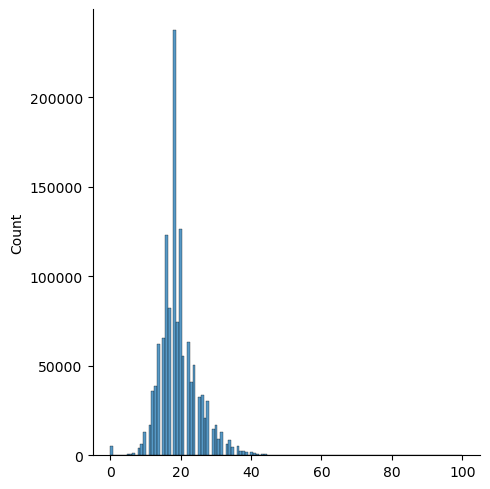

In [36]:
sns.displot(
    # x=v[np.where(~np.isnan(v)&(v<50))], kind='hist', bins=128
    x=v, kind='hist', bins=128
)

In [66]:
df_all.filter(
    (pl.col("event_full_name").str.to_lowercase().str.contains("body fluid culture"))&
    (pl.col("event_full_name").str.to_lowercase().str.
     contains(r"afb smear|result|isolate 1|culture status|gram st|gram stain|vanab gene bcid|ndm gene|oxa gene bcid|cdx-m gene bcid"))
)['Type', 'EVENT_NAME', 'Event_Grouper'].unique().to_pandas()

,Type,EVENT_NAME,Event_Grouper
0,Order Result - Lab,STENOTROPHOMONAS MALTOPHILIA BCID,Body Fluid Cultures
1,Order Result - Lab,ENTEROBACTERALES,Body Fluid Cultures
2,Order Result - Lab,KLEBSIELLA OXYTOCA BCID,Body Fluid Cultures
3,Order Result - Lab,KLEBSIELLA AEROGENES GROUP BCID,Body Fluid Cultures
4,Order - Procedure,CULTURE CSF + GRAM STAIN,Body Fluid Cultures
5,Order Result - Microbiology,CULTURE SALMONELLA,Body Fluid Cultures
6,Order Result - Lab,SERRATIA MARCESCENS BCID,Body Fluid Cultures
7,Order Result - Lab,VANAB GENE BCID,Body Fluid Cultures
8,Order Result - Lab,LISTERIA MONOCYTOGENES BCID,Body Fluid Cultures
9,Order Result - Lab,BACTEROIDES FRAGILIS BCID,Body Fluid Cultures


# Baseline join

In [86]:
lf_all_base = lf_all.join(
    lf_baseline,
    how='left',
    on=['PAT_ENC_CSN_ID']
)

In [87]:
lf_baseline.select(BASELINE_COLS[0]).collect()[BASELINE_COLS[0]].is_null().sum()

1152

In [88]:
df_enc_baseline = lf_baseline.collect()

In [89]:
df_enc_baseline[BASELINE_COLS[0]].is_null().sum()

1152

In [90]:
df_base_pat_sbp = df_enc_baseline.select("PAT_ENC_CSN_ID", BASELINE_COLS[0])
df_all_pat_sbp = lf_all_base.select("PAT_ENC_CSN_ID", BASELINE_COLS[0]).group_by("PAT_ENC_CSN_ID").agg(pl.col(BASELINE_COLS[0]).first()).collect()

In [99]:
for c in BASELINE_COLS:
	print(c)
	print(df_enc_baseline.group_by("PAT_ENC_CSN_ID").agg(pl.col(c).min().alias('first'), pl.col(c).max().alias('last')).filter(pl.col('first')!=pl.col("last")))
	print("="*60)

Baseline_SBP
shape: (0, 3)
┌────────────────┬───────┬──────┐
│ PAT_ENC_CSN_ID ┆ first ┆ last │
│ ---            ┆ ---   ┆ ---  │
│ i64            ┆ i64   ┆ i64  │
╞════════════════╪═══════╪══════╡
└────────────────┴───────┴──────┘
Baseline_DBP
shape: (0, 3)
┌────────────────┬───────┬──────┐
│ PAT_ENC_CSN_ID ┆ first ┆ last │
│ ---            ┆ ---   ┆ ---  │
│ i64            ┆ i64   ┆ i64  │
╞════════════════╪═══════╪══════╡
└────────────────┴───────┴──────┘
Baseline_RespiratoryRate
shape: (0, 3)
┌────────────────┬───────┬──────┐
│ PAT_ENC_CSN_ID ┆ first ┆ last │
│ ---            ┆ ---   ┆ ---  │
│ i64            ┆ i64   ┆ i64  │
╞════════════════╪═══════╪══════╡
└────────────────┴───────┴──────┘
Baseline_PulseRate
shape: (0, 3)
┌────────────────┬───────┬──────┐
│ PAT_ENC_CSN_ID ┆ first ┆ last │
│ ---            ┆ ---   ┆ ---  │
│ i64            ┆ i64   ┆ i64  │
╞════════════════╪═══════╪══════╡
└────────────────┴───────┴──────┘
Baseline_Creatinine
shape: (0, 3)
┌────────────────┬──────

In [92]:
df_base_pat_sbp.sort(by=['Baseline_SBP', 'PAT_ENC_CSN_ID']) == df_all_pat_sbp.sort(by=['Baseline_SBP', 'PAT_ENC_CSN_ID'])

PAT_ENC_CSN_ID,Baseline_SBP
bool,bool
true,null
true,null
true,null
true,null
false,null
…,…
true,true
true,false
false,true


In [93]:
df_base_pat_sbp.sort(by=['Baseline_SBP', 'PAT_ENC_CSN_ID'])


PAT_ENC_CSN_ID,Baseline_SBP
i64,i64
711219567,null
713249637,null
713257513,null
713608612,null
713699611,null
…,…
739525091,179
720499874,183
734813827,183


In [94]:
df_all_pat_sbp.sort(by=['Baseline_SBP', 'PAT_ENC_CSN_ID'])

PAT_ENC_CSN_ID,Baseline_SBP
i64,i64
711219567,null
713249637,null
713257513,null
713608612,null
714295799,null
…,…
739525091,179
720499874,180
728725325,183


In [80]:
pat_all = lf_all.select("PAT_ENC_CSN_ID").collect()['PAT_ENC_CSN_ID'].unique()
pat_base = lf_baseline.select("PAT_ENC_CSN_ID").collect()['PAT_ENC_CSN_ID'].unique()

In [70]:
lf_all.filter(pl.col("PAT_ENC_CSN_ID") == 723913607).collect()

PAT_ENC_CSN_ID,PAT_MRN_ID,PAT_ID,Ethnicity,FirstRace,Sex,Coverage_Financial_Class_Grouper,Pt_Arrival,Admit_Time,DateAdmitKey,Patient_Age,Chief_Complaint,Chief_Complaint_All,Baseline_SBP,Baseline_LVEF,Admitted_From_ED,LOS_Days,Hours_in_ED,Event_DateTime,Type,EVENT_NAME,Event_Grouper,Result_Flag,MEAS_VALUE,Sepsis_Category,FLAG_DEATH_CLARITY,event_full_name
i64,i64,str,str,str,str,str,datetime[μs],datetime[μs],i64,f64,str,str,i64,i64,str,i64,i64,datetime[μs],str,str,str,str,str,str,i64,str
723913607,98581505,"""Z11040832""","""Non-Hispanic/Latino""","""Black or African American""","""Male""","""Medicare""",2025-03-25 03:18:00,2025-03-26 02:18:00,20250325,73.919233,"""TINGLING""","""TINGLING,LOWER EXTREMITY WEAKN…",184,null,"""Yes""",27,23,2025-03-26 10:19:00,"""Flowsheet""","""BLOOD PRESSURE""","""Blood Pressure""",null,null,"""NPOA-3""",0,"""flowsheet_blood pressure_blood…"
723913607,98581505,"""Z11040832""","""Non-Hispanic/Latino""","""Black or African American""","""Male""","""Medicare""",2025-03-25 03:18:00,2025-03-26 02:18:00,20250325,73.919233,"""TINGLING""","""TINGLING,LOWER EXTREMITY WEAKN…",184,null,"""Yes""",27,23,2025-03-26 10:19:00,"""Flowsheet""","""SBP""","""Blood Pressure""",""" …","""75.0""","""NPOA-3""",0,"""flowsheet_sbp_blood pressure"""
723913607,98581505,"""Z11040832""","""Non-Hispanic/Latino""","""Black or African American""","""Male""","""Medicare""",2025-03-25 03:18:00,2025-03-26 02:18:00,20250325,73.919233,"""TINGLING""","""TINGLING,LOWER EXTREMITY WEAKN…",184,null,"""Yes""",27,23,2025-03-26 10:19:00,"""Flowsheet""","""SBP""","""Blood Pressure""",null,"""169.0""","""NPOA-3""",0,"""flowsheet_sbp_blood pressure"""
723913607,98581505,"""Z11040832""","""Non-Hispanic/Latino""","""Black or African American""","""Male""","""Medicare""",2025-03-25 03:18:00,2025-03-26 02:18:00,20250325,73.919233,"""TINGLING""","""TINGLING,LOWER EXTREMITY WEAKN…",184,null,"""Yes""",27,23,2025-03-27 00:00:00,"""Flowsheet""","""BLOOD PRESSURE""","""Blood Pressure""",null,null,"""NPOA-3""",0,"""flowsheet_blood pressure_blood…"
723913607,98581505,"""Z11040832""","""Non-Hispanic/Latino""","""Black or African American""","""Male""","""Medicare""",2025-03-25 03:18:00,2025-03-26 02:18:00,20250325,73.919233,"""TINGLING""","""TINGLING,LOWER EXTREMITY WEAKN…",184,null,"""Yes""",27,23,2025-03-27 00:00:00,"""Flowsheet""","""SBP""","""Blood Pressure""",""" …","""80.0""","""NPOA-3""",0,"""flowsheet_sbp_blood pressure"""
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
723913607,98581505,"""Z11040832""","""Non-Hispanic/Latino""","""Black or African American""","""Male""","""Medicare""",2025-03-25 03:18:00,2025-03-26 02:18:00,20250325,73.919233,"""TINGLING""","""TINGLING,LOWER EXTREMITY WEAKN…",184,null,"""Yes""",27,23,2025-03-25 13:42:45,"""Medication - Administration""","""ACETAMINOPHEN 500 MG TAB""","""Analgesic Non-Narcotics""",null,"""1000""","""NPOA-3""",0,"""medication - administration_ac…"
723913607,98581505,"""Z11040832""","""Non-Hispanic/Latino""","""Black or African American""","""Male""","""Medicare""",2025-03-25 03:18:00,2025-03-26 02:18:00,20250325,73.919233,"""TINGLING""","""TINGLING,LOWER EXTREMITY WEAKN…",184,null,"""Yes""",27,23,2025-03-25 21:26:35,"""Medication - Administration""","""ACETAMINOPHEN 500 MG TAB""","""Analgesic Non-Narcotics""",null,"""1000""","""NPOA-3""",0,"""medication - administration_ac…"
723913607,98581505,"""Z11040832""","""Non-Hispanic/Latino""","""Black or African American""","""Male""","""Medicare""",2025-03-25 03:18:00,2025-03-26 02:18:00,20250325,73.919233,"""TINGLING""","""TINGLING,LOWER EXTREMITY WEAKN…",184,null,"""Yes""",27,23,2025-03-25 05:22:00,"""Order - Medication""","""ONDANSETRON HCL (PF) 4 MG/2 ML…","""Antiemetics""",null,"""4""","""NPOA-3""",0,"""order - medication_ondansetron…"


In [95]:
lf_baseline.select(
    pl.col("PAT_ENC_CSN_ID").n_unique().alias("n_unique"),
    pl.len().alias("n_rows")
).collect()

n_unique,n_rows
u32,u32
3990,3990


In [50]:
lf_all_base.select("PAT_ENC_CSN_ID", BASELINE_COLS[0]).group_by("PAT_ENC_CSN_ID").agg(pl.col(BASELINE_COLS[0]).last()).collect()[BASELINE_COLS[0]].is_null().sum()

997

In [42]:
lf_baseline.collect_schema().names()

['PAT_ENC_CSN_ID',
 'EncounterKey',
 'DateAdmitKey',
 'Pt_Arrival',
 'Admit_Time',
 'Admitted_From_ED',
 'LOS_Days',
 'Hours_in_ED',
 'PAT_ID',
 'PAT_MRN_ID',
 'Sex',
 'FirstRace',
 'Ethnicity',
 'Coverage_Financial_Class_Grouper',
 'Patient_Age',
 'Chief_Complaint',
 'Chief_Complaint_All',
 'Baseline_SBP',
 'Baseline_DBP',
 'Baseline_RespiratoryRate',
 'Baseline_PulseRate',
 'Baseline_Creatinine',
 'Baseline_Bilirubin',
 'Baseline_Platelets',
 'Baseline_WBC',
 'Baseline_BUN',
 'Baseline_LVEF',
 'Sepsis_Category',
 'FLAG_DEATH_CLARITY']

In [10]:
df_all = lf_all.collect()

# Important columns name not to forget
### Datetime cols
['Pt_Arrival', 'Admit_Time', 'Event_DateTime']
### Dynamic feature cols
['EVENT_NAME', 'Type', 'Event_Grouper', 'MEAS_VALUE', 'Result_Flag']
### Static cols
['PAT_ENC_CSN_ID',
'PAT_MRN_ID',
 'PAT_ID',
 'Ethnicity',
 'FirstRace',
 'Sex',
 'Coverage_Financial_Class_Grouper',
 'Patient_Age',
 'Chief_Complaint',
 'Chief_Complaint_All',
 'Baseline_SBP',
 'Baseline_LVEF',
 ]
 ### Target COls
 [
    'Sepsis_Category',
    'FLAG_DEATH_CLARITY'
 ]

In [18]:
df_all.filter(pl.col("Event_Grouper").str.to_lowercase().str.contains('culture'))['Event_Grouper'].unique()

Event_Grouper
str
"""Body Fluid Cultures"""


In [ ]:

included_cultures = [
    # Blood cultures
    "CULTURE BLOOD",
    "CULTURE BLOOD ID MALDI - AEROBIC",
    "CULTURE BLOOD ID MALDI - ANAEROBIC",
    "CULTURE BLOOD ID MALDI-AEROBIC",
    "CULTURE BLOOD ID MALDI-ANAEROBIC",
    "CULTURE BLOOD ID NAAT- AEROBIC",
    "CULTURE BLOOD ID NAAT- ANAEROBIC",

    # Fungal and mycobacterial blood cultures
    "FUNGAL BLOOD CULTURE",
    "FUNGAL CULTURE, BLOOD",
    "MYCOBACTERIAL CULTURE, BLOOD",
    "AFB BLOOD CULTURE",

    # Sterile site cultures
    "CULTURE STERILE SITE",
    "CULTURE CSF + GRAM STAIN",
    "CULTURE ANAEROBIC",
    "CULTURE AEROBIC + ANAEROBIC + GRAM STAIN",
    "CULTURE AEROBIC AND ANAEROBIC RESULT",

    # Device-related sterile cultures
    "CULTURE CATH TIP",
    "CULTURE URINE",
    "CULTURE SPUTUM + SCREENING SMEAR",
    "CULTURE RESPIRATORY (NON SPUTUM) + STAIN",
]

excluded_cultures = [
    # BCID organism identifications (results, not orders)
    "COAGULASE-NEGATIVE STAPHYLOCOCCUS BCID",
    "KLEBSIELLA AEROGENES GROUP BCID",
    "KLEBSIELLA PNEUMONIAE GROUP BCID",
    "KLEBSIELLA OXYTOCA BCID",
    "ESCHERICHIA COLI BCID",
    "SERRATIA MARCESCENS BCID",
    "ACINETOBACTER CALCOACETICUS-BAUMANNII COMPLEX BCID",
    "STENOTROPHOMONAS MALTOPHILIA BCID",
    "ENTEROBACTER CLOACAE COMPLEX BCID",
    "STAPHYLOCOCCUS SP BCID",
    "STAPHYLOCOCCUS LUGDUNENSIS BCID",
    "STAPHYLOCOCCUS AUREUS BCID",
    "STREPTOCOCCUS SP BCID",
    "STREPTOCOCCUS PNEUMONIAE BCID",
    "GROUP B STREPTOCOCCUS BCID",
    "ENTEROCOCCUS FAECALIS BCID",
    "ENTEROCOCCUS FAECIUM BCID",
    "PROTEUS SP BCID",
    "HAEMOPHILUS INFLUENZAE BCID",
    "PSEUDOMONAS AERUGINOSA BCID",
    "SALMONELLA SP BCID",
    "BACTEROIDES FRAGILIS BCID",
    "LISTERIA MONOCYTOGENES BCID",
    "ENTEROBACTERALES",

    # Resistance and gene markers
    "CTX-M GENE BCID",
    "OXA GENE BCID",
    "NDM GENE",
    "VANAB GENE BCID",
    "MEC A/C AND MREJ (MRSA) GENE",

    # Fungal or organism species results
    "CANDIDA ALBICANS",
    "CANDIDA KRUSEI",
    "CANDIDA PARAPSILOSIS",
    "CANDIDA TROPICALIS",
    "NAKASEOMYCES CANDIDA GLABRATA",
    "CANDIDA AURIS",
    "CRYPTOCOCCUS NEOFORMANS/GATTII",

    # Stains, smears, and microscopy
    "GRAM STAIN",
    "GRAM ST",
    "AFB SMEAR",
    "MODIFIED ACID FAST STAIN",
    "FUNGAL SMEAR",

    # Status, metadata, and generic rows
    "BCID NAAT INTERPRETATION",
    "CULTURE STATUS",
    "RESULT",
    "ISOLATE 1",
    "CULTURE SOURCE",
    "CULTURE",
]
included_cultures_lowercase = list(map(lambda x: x.lower(), included_cultures))

['culture blood',
 'culture blood id maldi - aerobic',
 'culture blood id maldi - anaerobic',
 'culture blood id maldi-aerobic',
 'culture blood id maldi-anaerobic',
 'culture blood id naat- aerobic',
 'culture blood id naat- anaerobic',
 'fungal blood culture',
 'fungal culture, blood',
 'mycobacterial culture, blood',
 'afb blood culture',
 'culture sterile site',
 'culture csf + gram stain',
 'culture anaerobic',
 'culture aerobic + anaerobic + gram stain',
 'culture aerobic and anaerobic result',
 'culture cath tip',
 'culture urine',
 'culture sputum + screening smear',
 'culture respiratory (non sputum) + stain']

In [27]:
def get_AI_based_filter():
    expr_antibiotic_filter = (
        pl.col("event_full_name").str.ends_with("antibiotics") & 
        ~pl.col("event_full_name").str.contains(r"oral |topical|ophthalmic|otic|intravitreal|irrigation|lock|inhaled-only") 
    )
    expr_culture_filter = (
        pl.col("event_full_name").str.ends_with("body fluid cultures") & 
        pl.col("event_full_name").str.contains(fr"{'|'.join(included_cultures_lowercase)}") 
        
    )
    return expr_antibiotic_filter, expr_culture_filter

def get_all_antibiotic_cultures():
    expr_antibiotic_filter = (
        pl.col("event_full_name").str.ends_with("antibiotics") 
    )
    expr_culture_filter = (
        pl.col("event_full_name").str.ends_with("body fluid cultures") 
    )
    return expr_antibiotic_filter, expr_culture_filter

def get_expressions(with_AI_filter=True):
    if with_AI_filter:
        return get_AI_based_filter()
    else:
        return get_all_antibiotic_cultures()

In [28]:
expr_antibiotic, expr_cultur = get_expressions(True)

In [32]:
df_culture_antibiotic = df_all.filter(expr_antibiotic)

In [33]:
df_culture_antibiotic['event_full_name'].unique().to_list()

[]

In [13]:
df_all['Event_Grouper'].unique().to_list()

['LVEF',
 'BMI',
 'Lymphocytes Percent',
 'Norepinephrine',
 'IMMATURE GRAN ABS',
 'Antiemetics',
 'nRBC',
 'PCO2',
 'O2 Flow Rate',
 'Pain Scale',
 'Epinephrine',
 'FiO2',
 'Blood Urea Nitrogen',
 'Body Fluid Cultures',
 'RDW',
 'AST',
 'Urine Output',
 'Temperature',
 'Neurological Assessment',
 'Vent On/Off',
 'PH ART',
 'MONOS PCT',
 'Oxygen Delivery',
 'Platelet Count',
 'Anti-Rheumatics',
 'Bilirubin',
 'UTI',
 'Glasgow Coma Score',
 'Respirations',
 'NEUTROS ABS',
 'Vasopressin',
 'Absolute Lymphocytes',
 'Phenylephrine',
 'Creatinine',
 'Skin Assessment',
 'Severe Sepsis',
 'MCHC',
 'WBC',
 'RBC',
 'Pulse',
 'Septic Shock',
 'Dopamine',
 'Respiratory Assessment',
 'Antibiotics',
 'Sepsis',
 'Fluid Resuscitation',
 'Analgesic Non-Narcotics',
 'Imaging',
 'PaO2',
 'Chloride',
 'Blood Pressure',
 'MONOS ABS',
 'Weight',
 'Genitourinary Assessment',
 'Other',
 'ALBUMIN',
 'Lactate',
 'EKG',
 'PROCALCITONIN',
 'Gastrointestinal Assessment',
 'Dobutamine',
 'NEUTROS PCT',
 'Sodium',


In [25]:
lf_list[0].collect_schema().names()

['PAT_ENC_CSN_ID',
 'PAT_MRN_ID',
 'PAT_ID',
 'Ethnicity',
 'FirstRace',
 'Sex',
 'Coverage_Financial_Class_Grouper',
 'Pt_Arrival',
 'Admit_Time',
 'DateAdmitKey',
 'Patient_Age',
 'Chief_Complaint',
 'Chief_Complaint_All',
 'Baseline_SBP',
 'Baseline_LVEF',
 'Before_Admit_YN',
 'Admitted_From_ED',
 'LOS_Days',
 'Hours_in_ED',
 'Event_ID',
 'Event_DateTime',
 'Type',
 'EVENT_NAME',
 'Event_Grouper',
 'Result_Flag',
 'MEAS_VALUE',
 'MEAS_VALUE_RATE',
 'MEAS_VALUE_CHAR',
 'Sepsis_Category',
 'FLAG_DEATH_CLARITY']

In [21]:
temp_schema

Schema([('PAT_ENC_CSN_ID', Int64),
        ('PAT_MRN_ID', Int64),
        ('PAT_ID', String),
        ('Ethnicity', String),
        ('FirstRace', String),
        ('Sex', String),
        ('Coverage_Financial_Class_Grouper', String),
        ('Pt_Arrival', String),
        ('Admit_Time', String),
        ('DateAdmitKey', Int64),
        ('Patient_Age', Float64),
        ('Chief_Complaint', String),
        ('Chief_Complaint_All', String),
        ('Baseline_SBP', Int64),
        ('Baseline_LVEF', Int64),
        ('Before_Admit_YN', String),
        ('Admitted_From_ED', String),
        ('LOS_Days', Int64),
        ('Hours_in_ED', Int64),
        ('Event_ID', Int64),
        ('Event_Datetime', String),
        ('Type', String),
        ('EVENT_NAME', String),
        ('Event_Grouper', String),
        ('Result_Flag', String),
        ('MEAS_VALUE', Float64),
        ('MEAS_VALUE_RATE', String),
        ('MEAS_VALUE_CHAR', String),
        ('Sepsis_Category', String),
        ('FLAG_DEA

In [15]:
lf_list[0].collect_schema()['PAT_ENC_CSN_ID']

Int64

In [14]:
for k in lf_list[0].collect_schema().items():
    print(k)
    break

('PAT_ENC_CSN_ID', Int64)


In [9]:
lf_all = pl.concat(lf_list, how='vertical')

In [11]:
lf_all.head()

InvalidOperationError: 'union'/'concat' inputs should all have the same schema,got
Schema:
name: PAT_ENC_CSN_ID, field: Int64
name: PAT_MRN_ID, field: Int64
name: PAT_ID, field: String
name: Ethnicity, field: String
name: FirstRace, field: String
name: Sex, field: String
name: Coverage_Financial_Class_Grouper, field: String
name: Pt_Arrival, field: String
name: Admit_Time, field: String
name: DateAdmitKey, field: Int64
name: Patient_Age, field: Float64
name: Chief_Complaint, field: String
name: Chief_Complaint_All, field: String
name: Baseline_SBP, field: Int64
name: Baseline_LVEF, field: Int64
name: Before_Admit_YN, field: String
name: Admitted_From_ED, field: String
name: LOS_Days, field: Int64
name: Hours_in_ED, field: Int64
name: Event_ID, field: Int64
name: Event_Datetime, field: String
name: Type, field: String
name: EVENT_NAME, field: String
name: Event_Grouper, field: String
name: Result_Flag, field: String
name: MEAS_VALUE, field: Float64
name: MEAS_VALUE_RATE, field: String
n

# Old dataset

In [2]:
# Constants
RAW_DATA_PATH = "../data/"
files = sorted(os.listdir(RAW_DATA_PATH))

In [13]:
# Confirm that the schemas match over different csv files
schema = {}
pats = {}
for file in files:
    if not file.endswith('.csv'):
        print(f"{file} can not be read by pl.scan_csv(...)")
    fpath = os.path.join(RAW_DATA_PATH, file) 
    df = pl.scan_csv(
        fpath
    )
    uniq_pats = df.select("PAT_ENC_CSN_ID").unique()
    schema[file] = uniq_pats

preprocessed_all_data.parquet can not be read by pl.scan_csv(...)


In [11]:
schema

{'Diagnosis Audit - Nov 2024 - Oct 2025.csv': <LazyFrame [1 col, {"PAT_ENC_CSN_ID": Int64}] at 0x29DE1195580>,
 'Flowsheets - Nov 2024 - Oct 2025.csv': <LazyFrame [1 col, {"PAT_ENC_CSN_ID": Int64}] at 0x29DE1195610>,
 'Lab Order Results - Nov 2024 - Oct 2025.csv': <LazyFrame [1 col, {"PAT_ENC_CSN_ID": Int64}] at 0x29DE11954F0>,
 'Medication Admin - Nov 2024 - Oct 2025.csv': <LazyFrame [1 col, {"PAT_ENC_CSN_ID": Int64}] at 0x29DE1195670>,
 'Medication Orders - Nov 2024 - Oct 2025.csv': <LazyFrame [1 col, {"PAT_ENC_CSN_ID": Int64}] at 0x29DE11956D0>,
 'Procedure Orders - Nov 2024 - Oct 2025.csv': <LazyFrame [1 col, {"PAT_ENC_CSN_ID": Int64}] at 0x29DE1195370>}

In [14]:
pat_diag = schema['Diagnosis Audit - Nov 2024 - Oct 2025.csv'].collect_async()
pat_flow = schema['Flowsheets - Nov 2024 - Oct 2025.csv'].collect_async()
pat_labord = schema['Lab Order Results - Nov 2024 - Oct 2025.csv'].collect_async()
pat_medadmin = schema['Medication Admin - Nov 2024 - Oct 2025.csv'].collect_async()
pat_medord = schema['Medication Orders - Nov 2024 - Oct 2025.csv'].collect_async()
pat_proc = schema['Procedure Orders - Nov 2024 - Oct 2025.csv'].collect_async()

In [16]:
pat_diag = pat_diag.result.result()
pat_flow = pat_flow.result.result()
pat_labord = pat_labord.result.result()
pat_medadmin = pat_medadmin.result.result()
pat_medord = pat_medord.result.result()
pat_proc = pat_proc.result.result()

AttributeError: 'DataFrame' object has no attribute 'result'

In [17]:
len(pat_flow), len(pat_labord), len(pat_diag), len(pat_medadmin), len(pat_medord), len(pat_proc)

(3930, 3927, 3930, 3923, 3927, 3922)

In [18]:
uniq_pats = set(pat_flow['PAT_ENC_CSN_ID']).intersection(set(pat_diag['PAT_ENC_CSN_ID'])).\
    intersection(set(pat_labord["PAT_ENC_CSN_ID"])).intersection(set(pat_medadmin["PAT_ENC_CSN_ID"])).\
        intersection(set(pat_medord["PAT_ENC_CSN_ID"])).intersection(set(pat_proc['PAT_ENC_CSN_ID']))

In [10]:
uniq_pats

{720642049,
 730759171,
 727449603,
 723378184,
 737550346,
 721281035,
 735141902,
 715653135,
 728006673,
 719249429,
 730734613,
 733347863,
 725368858,
 715079708,
 721764380,
 729317406,
 720609314,
 719331363,
 718381091,
 724287528,
 720863272,
 716603434,
 737075249,
 720101426,
 720126004,
 727375926,
 738050103,
 718069817,
 729874489,
 729399356,
 720068669,
 720494656,
 720126017,
 724525120,
 724877382,
 737067079,
 723804233,
 718979146,
 723361867,
 728981577,
 715939918,
 723812430,
 720322641,
 719536209,
 726351955,
 730079317,
 715939928,
 724844633,
 718823514,
 728989787,
 727441497,
 731226200,
 729776220,
 732586081,
 730275938,
 734543973,
 715677799,
 726761576,
 729210984,
 728154215,
 727449706,
 729227375,
 730759281,
 722919539,
 732635251,
 737075318,
 736895100,
 724615294,
 717267070,
 731693184,
 716800126,
 726827135,
 737116298,
 721248395,
 730742926,
 715088016,
 729890961,
 717562002,
 722960530,
 717103252,
 716251285,
 718028949,
 725336215,
 719

In [11]:
rpats = np.random.choice(list(uniq_pats), 350, replace=False)

In [19]:
df_t = []
for file in files:
    if not file.endswith('.csv'):
        print(f"{file} can not be read by pl.scan_csv(...)")
    fpath = os.path.join(RAW_DATA_PATH, file) 
    df = pl.scan_csv(
        fpath, null_values=["NULL", 'null', "Null"], infer_schema_length=int(1e7)
    )
    # df_t.append(df.filter(pl.col("PAT_ENC_CSN_ID").is_in(rpats)).collect_async())
    df_t.append(df.collect_async())
    

preprocessed_all_data.parquet can not be read by pl.scan_csv(...)


In [20]:
df_data = []
for dd in df_t:
    if dd.result.done():
        df_data.append(dd.result.result())
len(df_data)

ComputeError: could not parse `PAT_MRN_ID�� ���&��<6 (��    �k      bnL   (�/� 1u 4   Z53409953397161	105420534491734 <���Jԟ��\��  �� Ȋ 6 (Z5340995	Z10542053   Ê�������������������������������������������������������������������������������������������������������������������������������������������������������������������������������������������������������������������������������������������������������������������������������������������������������������������������������������������������������������������������������������������������������������������������������������������������������������������������������������������������������������������������������������������������������������������������������������������������������������������������������������������������������������������������������������������������������������������������������������������������������������������������������������������������������������������������

In [10]:
for i, df_i in enumerate(df_data):
    df_i = df_i.with_columns(
        pl.col("Event_ID").cast(pl.Int64)
    )
    if 'Event_Datetime' in df_i.columns:
        df_i = df_i.rename({"Event_Datetime":"Event_DateTime"})
    df_data[i] = df_i

In [11]:
for df_i in df_data:
    if "Event_DateTime" not in df_i:
        print(df_i.columns)

In [12]:
for c in df_data[0].columns:
    for i in range(1, 6):
        if df_data[i].schema[c] != df_data[0].schema[c]:
            print(c)

In [13]:
df_all = pl.concat(df_data, how='vertical')

In [14]:
df_all.columns

['PAT_ENC_CSN_ID',
 'PAT_MRN_ID',
 'PAT_ID',
 'Ethnicity',
 'FirstRace',
 'Sex',
 'Coverage_Financial_Class_Grouper',
 'Pt_Arrival',
 'Admit_Time',
 'DateAdmitKey',
 'Patient_Age',
 'Chief_Complaint',
 'Chief_Complaint_All',
 'Before_Admit_YN',
 'Admitted_From_ED',
 'LOS_Days',
 'Hours_in_ED',
 'Event_ID',
 'Event_DateTime',
 'Type',
 'EVENT_NAME',
 'Event_Grouper',
 'Result_Flag',
 'MEAS_VALUE',
 'Sepsis_Category',
 'FLAG_DEATH_CLARITY']

In [15]:
df_all = df_all.sort(by=["PAT_ENC_CSN_ID", "Event_DateTime"])

In [16]:
df_all['Admit_Time']

Admit_Time
str
"""2024-01-07 02:…"
"""2024-01-07 02:…"
"""2024-01-07 02:…"
"""2024-01-07 02:…"
"""2024-01-07 02:…"
…
"""2025-10-27 02:…"
"""2025-10-27 02:…"
"""2025-10-27 02:…"


In [17]:
if df_all.schema['Admit_Time'] in [pl.Utf8, pl.String]:
    df_all = df_all.with_columns(
        pl.col("Admit_Time").str.strptime(pl.Datetime, format="%Y-%m-%d %H:%M:%S%.f")
    )

if df_all.schema['Event_DateTime'] in [pl.Utf8, pl.String]:
    df_all = df_all.with_columns(
        pl.col("Event_DateTime").str.strptime(pl.Datetime, format="%Y-%m-%d %H:%M:%S%.f")
    )

if df_all.schema['Pt_Arrival'] in [pl.Utf8, pl.String]:
    df_all = df_all.with_columns(
        pl.col("Pt_Arrival").str.strptime(pl.Datetime, format="%Y-%m-%d %H:%M:%S%.f")
    )


In [18]:
drop_cols = []
for col in ["DateADmitKey", "Chief_Complaint", "Event_ID"]:
    if col in df_all.columns:
        drop_cols.append(col)

df_all = df_all.drop(drop_cols)

In [19]:
df_all.shape

(7758284, 24)

In [20]:
df_all.schema, df_all.shape

(OrderedDict([('PAT_ENC_CSN_ID', Int64),
              ('PAT_MRN_ID', Int64),
              ('PAT_ID', String),
              ('Ethnicity', String),
              ('FirstRace', String),
              ('Sex', String),
              ('Coverage_Financial_Class_Grouper', String),
              ('Pt_Arrival', Datetime(time_unit='ns', time_zone=None)),
              ('Admit_Time', Datetime(time_unit='ns', time_zone=None)),
              ('DateAdmitKey', Int64),
              ('Patient_Age', Float64),
              ('Chief_Complaint_All', String),
              ('Before_Admit_YN', String),
              ('Admitted_From_ED', String),
              ('LOS_Days', Int64),
              ('Hours_in_ED', Int64),
              ('Event_DateTime', Datetime(time_unit='ns', time_zone=None)),
              ('Type', String),
              ('EVENT_NAME', String),
              ('Event_Grouper', String),
              ('Result_Flag', String),
              ('MEAS_VALUE', String),
              ('Sepsis_Catego

In [37]:
df_all['Type'].unique().to_list()

['Order Result - Lab',
 'Diagnosis Audit - Add',
 'Order Result - Microbiology',
 'Medication - Administration',
 'Order - Medication',
 'Flowsheet',
 'Order - Procedure',
 'Diagnosis Audit - Remove']

In [41]:
df_all.filter(pl.col("Type") == "Diagnosis Audit - Add")['EVENT_NAME'].unique().to_list()

['Impairment of cognitive function',
 'Lymphoma (*)',
 'Multiple kidney stones',
 'Open wound of scrotum, subsequent encounter',
 'Central sleep apnea',
 'Vocal cord dysfunction',
 'Lung transplant status (*)',
 'Midline low back pain without sciatica, unspecified chronicity',
 'B-cell acute lymphoblastic leukemia (ALL) (*)',
 'Screening for malignant neoplasm of colon',
 'Terminal respiratory secretions',
 'Acute osteomyelitis involving pelvic region and thigh, right (*)',
 'Viral URI',
 'Pneumonia',
 'Obstruction of celiac artery',
 'Critical illness myopathy',
 'Fracture',
 'Debility',
 'Positive urine culture in cadaveric donor',
 'Other acquired hemolytic anemias (*)',
 'Consolidation of right upper lobe of lung (*)',
 'Localized swelling, mass and lump, neck',
 'Cystitis',
 'Bronchospasm',
 'Stenosis of prosthetic aortic valve, subsequent encounter',
 'Bladder perforation, intraoperative',
 'Chronic diarrhea',
 'Positive D dimer',
 'Chronic congestive heart failure (*)',
 'Hypoxi

In [21]:
df_all['Type'].unique().to_list()

['Order Result - Microbiology',
 'Order - Procedure',
 'Order - Medication',
 'Diagnosis Audit - Add',
 'Flowsheet',
 'Medication - Administration',
 'Order Result - Lab',
 'Diagnosis Audit - Remove']

In [22]:
df_all['Event_Grouper'].unique().to_list()

['Gastrointestinal Assessment',
 'Epinephrine',
 'NEUTROS PCT',
 'Body Fluid Cultures',
 'NEUTROS ABS',
 'Sodium',
 'Platelet Count',
 'Phenylephrine',
 'FiO2',
 'Antiemetics',
 'Blood Pressure',
 'RDW',
 'EKG',
 'Dopamine',
 'Respiratory Assessment',
 'Weight',
 'Antibiotics',
 'PROCALCITONIN',
 'ALBUMIN',
 'Dobutamine',
 'Skin Assessment',
 'IMMATURE GRAN PCT',
 'Braden Scale',
 'WBC',
 'Bilirubin',
 'MONOS ABS',
 'Anti-Rheumatics',
 'PaO2',
 'Analgesic Non-Narcotics',
 'O2 Flow Rate',
 'Vent On/Off',
 'AST',
 'Lactate',
 'Pain Scale',
 'Septic Shock',
 'IMMATURE GRAN ABS',
 'BMI',
 'Sepsis',
 'Genitourinary Assessment',
 'Glasgow Coma Score',
 'Neurological Assessment',
 'Severe Sepsis',
 'Other',
 'Pulse',
 'Chloride',
 'MCHC',
 'Temperature',
 'Blood Urea Nitrogen',
 'Oxygen Delivery',
 'MONOS PCT',
 'Vasopressin',
 'Imaging',
 'RBC',
 'Absolute Lymphocytes',
 'Urine Output',
 'nRBC',
 'Respirations',
 'Norepinephrine',
 'PH ART',
 'UTI',
 'Lymphocytes Percent',
 'Creatinine']

In [28]:
df_all = df_all.with_columns(
    event_full_name=pl.col("Type")+"__"+pl.col("EVENT_NAME")+"__"+pl.col("Event_Grouper")
)

In [47]:
df_all.write_parquet("../data/preprocessed_all_data.parquet")

# Start reading preprocessed data from here

In [2]:
df_all = pl.read_parquet("../data/preprocessed_all_data.parquet")

In [3]:
df_all.shape

(7758284, 25)

In [4]:
all_flowsheet_names = df_all.filter(
    pl.col("Type") == "Flowsheet"
)['EVENT_NAME'].unique().to_list()

all_event_names = df_all['event_full_name'].unique().to_list()

NameError: name 'df_all' is not defined

In [46]:
df_all.head(50).select("PAT_ENC_CSN_ID", "Event_DateTime", "Type", "EVENT_NAME", 'MEAS_VALUE')

PAT_ENC_CSN_ID,Event_DateTime,Type,EVENT_NAME,MEAS_VALUE
i64,datetime[ns],str,str,str
695960811,2024-01-06 15:30:00,"""Flowsheet""","""WEIGHT/SCALE""","""3840"""
695960811,2024-01-06 15:30:00,"""Flowsheet""","""BLOOD PRESSURE…","""105/50"""
695960811,2024-01-06 15:30:00,"""Flowsheet""","""RESPIRATIONS""","""18"""
695960811,2024-01-06 15:30:00,"""Flowsheet""","""PULSE""","""76"""
695960811,2024-01-06 15:30:00,"""Flowsheet""","""MODEL R BMI""","""33.5"""
…,…,…,…,…
695960811,2024-01-06 20:15:00,"""Flowsheet""","""TEMPERATURE""","""97.8"""
695960811,2024-01-06 20:15:00,"""Diagnosis Audi…","""Stage 3a chron…",null
695960811,2024-01-06 20:15:00,"""Flowsheet""","""RESPIRATIONS""","""13"""


In [43]:
df_all['Event_Grouper'].unique().to_list()

['EKG',
 'Sodium',
 'Epinephrine',
 'Chloride',
 'MONOS PCT',
 'AST',
 'Blood Pressure',
 'Imaging',
 'Dopamine',
 'Antiemetics',
 'RDW',
 'PH ART',
 'Oxygen Delivery',
 'PROCALCITONIN',
 'Anti-Rheumatics',
 'Other',
 'Phenylephrine',
 'Pulse',
 'Creatinine',
 'Dobutamine',
 'WBC',
 'Platelet Count',
 'Absolute Lymphocytes',
 'Bilirubin',
 'ALBUMIN',
 'BMI',
 'Pain Scale',
 'Lactate',
 'Skin Assessment',
 'PaO2',
 'RBC',
 'Braden Scale',
 'Sepsis',
 'Body Fluid Cultures',
 'Lymphocytes Percent',
 'UTI',
 'Urine Output',
 'Neurological Assessment',
 'Genitourinary Assessment',
 'O2 Flow Rate',
 'Blood Urea Nitrogen',
 'Norepinephrine',
 'MCHC',
 'Antibiotics',
 'Severe Sepsis',
 'Vent On/Off',
 'Temperature',
 'NEUTROS PCT',
 'Gastrointestinal Assessment',
 'nRBC',
 'IMMATURE GRAN ABS',
 'Vasopressin',
 'IMMATURE GRAN PCT',
 'NEUTROS ABS',
 'Septic Shock',
 'FiO2',
 'Weight',
 'MONOS ABS',
 'Glasgow Coma Score',
 'Analgesic Non-Narcotics',
 'Respirations',
 'Respiratory Assessment']

In [36]:
df_all.filter(pl.col('Event_Grouper').is_in(["Sepsis", "Severe Sepsis"]))["EVENT_NAME"].unique().to_list()

['Staphylococcus aureus septicemia (*)',
 'Sepsis due to Salmonella species with critical illness polyneuropathy without septic shock (*)',
 'Sepsis due to Pseudomonas species without acute organ dysfunction (*)',
 'Severe sepsis (*)',
 'Septicemia (*)',
 'Sepsis due to Citrobacter species (*)',
 'Sepsis due to other Streptococcus species without acute organ dysfunction (*)',
 'Sepsis due to Enterococcus with acute renal failure and metabolic encephalopathy (*)',
 'Sepsis with acute hypoxic respiratory failure without septic shock (*)',
 'Sepsis with acute liver failure without hepatic coma, due to unspecified organism, unspecified whether septic shock present (*)',
 'Sepsis due to methicillin susceptible Staphylococcus aureus (MSSA) with acute hypoxic respiratory failure, unspecified whether septic shock present (*)',
 'Staphylococcus aureus bacteremia with sepsis (*)',
 'Sepsis due to gram-negative urinary tract infection (*)',
 'Neutropenic sepsis (*)',
 'Sepsis with acute organ dys

In [29]:
SEPSIS_CONFIG['meta_data']

{'required_columns': ['encounter_id',
  'patient_id',
  'event_time',
  'event_type',
  'event_name',
  'event_value',
  'med_route',
  'med_status']}

In [50]:
df_all.filter(pl.col("Type") == "Order - Procedure")["Event_Grouper"].unique().to_list()

['Body Fluid Cultures', 'Imaging', 'EKG']

In [55]:
df_all['Type'].unique()

Type
str
"""Diagnosis Audi…"
"""Order Result -…"
"""Diagnosis Audi…"
"""Flowsheet"""
"""Medication - A…"
"""Order - Medica…"
"""Order Result -…"
"""Order - Proced…"


In [56]:
df_all.filter(pl.col("Type") == "Flowsheet")['EVENT_NAME'].unique().to_list()

['CPM S24 R AS SC BRADEN SCORE',
 'UTSW CPM CUSTOM S24 R AS GASTROINTESTINAL WDL',
 'PULSE',
 'UTSW ANES R AN URINE OUTPUT',
 'R UROSTOMY OUTPUT',
 'CPM S24 R AS ED GASTROINTESTINAL WDL',
 'CPM S24 R AS GENITOURINARY WDL',
 'UTSW R ED PRE HOSPITAL CARE EMS VITALS INV O2 DEVICE (L/MIN)',
 'CPM S24 R AS ED RESPIRATORY WDL',
 'GU - URINE OUTPUT (ML)',
 'TEMPERATURE',
 'CPM S24 R AS SC GLASGOW COMA SCALE SCORE',
 'CPM S24 R AS ED GENITOURINARY WDL',
 'RESPIRATIONS',
 'UTSW UH R REHAB URINE ACCIDENT',
 'URINE OUTPUT',
 'MODEL R BMI',
 'UTSW CPM CUSTOM S24 R AS COGNITIVE/NEURO/BEHAVIORAL WDL',
 'UTSW UH R RT VENT MANAGEMENT STATUS CHARGE',
 'R URINE OUTPUT',
 'CPM S24 R PRO OXYGEN THERAPY DEVICE',
 'R ED CLINICAL CALCULATOR - GLASGOW COMA SCALE SCORE',
 'UTSW CPM CUSTOM S24 R AS SKIN WDL',
 'CPM S24 R AS RESPIRATORY WDL',
 'WEIGHT/SCALE',
 'CPM S24 R INV DEVICE (OXYGEN THERAPY)',
 'PAIN SCALE (13)',
 'CPM S24 R INV FLOW (L/MIN) (OXYGEN THERAPY)',
 'BLOOD PRESSURE',
 'UTSW UH R UNMEASURED URI

In [52]:
df_all.filter(
    (pl.col("Type") == "Order - Procedure")
    &
    (pl.col("EVENT_NAME").str.to_lowercase().str.contains("drain"))
    )["EVENT_NAME"].unique().to_list()

['IR TUNNELED PLEURAL DRAINAGE CATHETER REMOVAL',
 'IR DRAIN PLACEMENT VISCERAL',
 'IR DRAIN PLACEMENT SOFT TISSUE',
 'IR DRAIN PLACEMENT PLEURAL',
 'IR LUMBAR DRAIN NEURO',
 'IR DRAIN PLACEMENT PERITONEAL OR RETROPERITONEAL',
 'IR TUNNELED PLEURAL DRAINAGE CATHETER PLACEMENT',
 'US DRAIN ABDOMEN AND OR PELVIS',
 'CT DRAIN PLACEMENT PELVIS',
 'CT DRAIN PLACEMENT ABDOMEN AND OR PELVIS',
 'IR DRAIN CHECK',
 'IR DRAINAGE CATHETER CHANGE',
 'IR DRAIN CATHETER EXCHANGE',
 'CT DRAIN PLACEMENT RENAL',
 'US DRAINAGE SOFT TISSUE',
 'IR BILIARY DRAIN EXCHANGE',
 'CT DRAIN PLACEMENT SOFT TISSUE',
 'IR DRAIN CATHETER CHECK',
 'CT DRAIN PLACEMENT PERITONEAL OR RETROPERITONEUM',
 'IR BILIARY DRAIN PLACEMENT',
 'IR TUNNELED PERITONEAL DRAINAGE CATHETER PLACEMENT',
 'US DRAINAGE RENAL']

In [42]:
list(filter(lambda x: 'diagnosis audit' in x.lower() and ('x-ray' in x.lower() or 'xray' in x.lower()), all_event_names))

['Diagnosis Audit - Add__Osteopenia determined by x-ray__Other',
 'Diagnosis Audit - Add__Abnormal chest x-ray__Other']

In [47]:
sorted(list(filter(lambda x: 'med' in x.lower() and  "antibiot" in x.lower() and ("iv" in x.lower() ), all_event_names)))

['Medication - Administration__ALTEPLASE (ACTIVASE) INTRAPLEURAL INJECTION__Antibiotics',
 'Medication - Administration__AMIKACIN IVPB__Antibiotics',
 'Medication - Administration__AMPHOTERICIN B LIPOSOME IVPB__Antibiotics',
 'Medication - Administration__AMPICILLIN IV 2G IN NS 100 ML (MINIBAG PLUS)__Antibiotics',
 'Medication - Administration__AMPICILLIN-SULBACTAM IN NS 3 GM IVPB__Antibiotics',
 'Medication - Administration__AZITHROMYCIN 250 MG IVPB __Antibiotics',
 'Medication - Administration__AZITHROMYCIN 500 MG IVPB (VIAL2BAG)__Antibiotics',
 'Medication - Administration__AZTREONAM (AZACTAM) 500 MG IV PUSH__Antibiotics',
 'Medication - Administration__AZTREONAM 1 G IV PUSH__Antibiotics',
 'Medication - Administration__AZTREONAM 2 G IV PUSH__Antibiotics',
 'Medication - Administration__CEFAZOLIN 2 G IV PUSH__Antibiotics',
 'Medication - Administration__CEFAZOLIN 2 GM IN 50 ML D5W IVPB__Antibiotics',
 'Medication - Administration__CEFAZOLIN 2 GM IVPB__Antibiotics',
 'Medication - Ad

In [29]:
df_all.filter(pl.col("EVENT_NAME") == "PLT ESTIMATE")["MEAS_VALUE"]

MEAS_VALUE
str
"""Decreased"""
"""Decreased"""
"""Decreased"""
"""Decreased"""
"""Decreased"""
…
"""Decreased"""
"""Decreased"""
"""Decreased"""


In [42]:
df_all.filter(pl.col("EVENT_NAME") == "BLOOD PRESSURE")

PAT_ENC_CSN_ID,PAT_MRN_ID,PAT_ID,Ethnicity,FirstRace,Sex,Coverage_Financial_Class_Grouper,Pt_Arrival,Admit_Time,DateAdmitKey,Patient_Age,Chief_Complaint_All,Before_Admit_YN,Admitted_From_ED,LOS_Days,Hours_in_ED,Event_DateTime,Type,EVENT_NAME,Event_Grouper,Result_Flag,MEAS_VALUE,Sepsis_Category,FLAG_DEATH_CLARITY,event_full_name
i64,i64,str,str,str,str,str,datetime[ns],datetime[ns],i64,f64,str,str,str,i64,i64,datetime[ns],str,str,str,str,str,str,i64,str
695960811,92882623,"""Z5340995""","""Non-Hispanic/L…","""Black or Afric…","""Male""","""Medicare""",2024-01-06 15:26:00,2024-01-07 02:50:00,20240106,62.685831,"""BLEEDING GUMS""","""Yes""","""Yes""",393,11,2024-01-06 15:30:00,"""Flowsheet""","""BLOOD PRESSURE…","""Blood Pressure…",null,"""105/50""","""NPOA-3""",0,"""Flowsheet__BLO…"
695960811,92882623,"""Z5340995""","""Non-Hispanic/L…","""Black or Afric…","""Male""","""Medicare""",2024-01-06 15:26:00,2024-01-07 02:50:00,20240106,62.685831,"""BLEEDING GUMS""","""Yes""","""Yes""",393,11,2024-01-06 17:41:00,"""Flowsheet""","""BLOOD PRESSURE…","""Blood Pressure…",null,"""119/60""","""NPOA-3""",0,"""Flowsheet__BLO…"
695960811,92882623,"""Z5340995""","""Non-Hispanic/L…","""Black or Afric…","""Male""","""Medicare""",2024-01-06 15:26:00,2024-01-07 02:50:00,20240106,62.685831,"""BLEEDING GUMS""","""Yes""","""Yes""",393,11,2024-01-06 20:15:00,"""Flowsheet""","""BLOOD PRESSURE…","""Blood Pressure…",null,"""101/64""","""NPOA-3""",0,"""Flowsheet__BLO…"
695960811,92882623,"""Z5340995""","""Non-Hispanic/L…","""Black or Afric…","""Male""","""Medicare""",2024-01-06 15:26:00,2024-01-07 02:50:00,20240106,62.685831,"""BLEEDING GUMS""","""Yes""","""Yes""",393,11,2024-01-06 20:30:00,"""Flowsheet""","""BLOOD PRESSURE…","""Blood Pressure…",null,"""114/62""","""NPOA-3""",0,"""Flowsheet__BLO…"
695960811,92882623,"""Z5340995""","""Non-Hispanic/L…","""Black or Afric…","""Male""","""Medicare""",2024-01-06 15:26:00,2024-01-07 02:50:00,20240106,62.685831,"""BLEEDING GUMS""","""Yes""","""Yes""",393,11,2024-01-06 20:40:00,"""Flowsheet""","""BLOOD PRESSURE…","""Blood Pressure…",null,"""121/59""","""NPOA-3""",0,"""Flowsheet__BLO…"
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
739134131,98447676,"""Z10906956""","""Non-Hispanic/L…","""White""","""Male""","""Medicare""",2025-10-26 20:22:00,2025-10-27 02:18:00,20251026,78.707734,"""VOMITING,HYPOT…","""Yes""","""Yes""",2,6,2025-10-27 00:20:00,"""Flowsheet""","""BLOOD PRESSURE…","""Blood Pressure…",null,"""61/46""","""POA-3""",1,"""Flowsheet__BLO…"
739134131,98447676,"""Z10906956""","""Non-Hispanic/L…","""White""","""Male""","""Medicare""",2025-10-26 20:22:00,2025-10-27 02:18:00,20251026,78.707734,"""VOMITING,HYPOT…","""Yes""","""Yes""",2,6,2025-10-27 01:01:00,"""Flowsheet""","""BLOOD PRESSURE…","""Blood Pressure…",null,"""104/55""","""POA-3""",1,"""Flowsheet__BLO…"
739134131,98447676,"""Z10906956""","""Non-Hispanic/L…","""White""","""Male""","""Medicare""",2025-10-26 20:22:00,2025-10-27 02:18:00,20251026,78.707734,"""VOMITING,HYPOT…","""Yes""","""Yes""",2,6,2025-10-27 01:20:00,"""Flowsheet""","""BLOOD PRESSURE…","""Blood Pressure…",null,"""103/63""","""POA-3""",1,"""Flowsheet__BLO…"


In [40]:
sorted(list(filter(lambda x: 'flowsheet' in x.lower() and ('temp' in x.lower()), all_event_names)))

['Flowsheet__TEMPERATURE__Temperature']

In [37]:
df_all.filter(pl.col("Event_Grouper")=='Respirations')['Type'].unique()

Type
str
"""Flowsheet"""


In [22]:
df_all['Type'].unique().to_list()

['Medication - Administration',
 'Flowsheet',
 'Order Result - Microbiology',
 'Order - Medication',
 'Order Result - Lab',
 'Order - Procedure',
 'Diagnosis Audit - Remove',
 'Diagnosis Audit - Add']

In [25]:
df_meds_cnt = df_all.filter(pl.col('Type')=='Medication - Administration')['EVENT_NAME'].value_counts(sort=True)

In [37]:
med = "PENICILLIN V POTASSIUM 500 MG TAB"

In [41]:
df_all.filter(pl.col("EVENT_NAME")==med)['Event_Grouper'].value_counts()

Event_Grouper,count
str,u32
"""Antibiotics""",196


In [70]:
df_all.filter(pl.col("EVENT_NAME").str.to_lowercase().str.contains("culture"))[['EVENT_NAME', "Event_Grouper"]]['EVENT_NAME'].unique().to_list()

['CULTURE STERILE SITE',
 'VRE (vancomycin resistant enterococcus) culture positive',
 'CULTURE BLOOD ID NAAT- ANAEROBIC',
 'Positive blood culture',
 'CULTURE FUNGAL WITH SMEAR',
 'CULTURE AFB + SMEAR',
 'CULTURE THROAT',
 'Positive blood cultures',
 'CULTURE CYSTIC FIBROSIS RESP (NON SPUTUM) + GRAM STAIN',
 'CULTURE CYSTIC FIBROSIS SPUTUM',
 'CULTURE BLOOD ID NAAT- AEROBIC',
 'CULTURE SOURCE',
 'CULTURE NOCARDIA WITH STAIN',
 'AFB BLOOD CULTURE',
 'FUNGAL CULTURE, BLOOD',
 'CULTURE STOOL',
 'CULTURE BLOOD ID MALDI - AEROBIC',
 'Blood culture positive for microorganism',
 'CULTURE BLOOD ID MALDI-ANAEROBIC',
 'CULTURE ANAEROBIC',
 'CULTURE, AEROBIC BACTERIA WITH GRAM STAIN',
 'FUNGAL BLOOD CULTURE',
 'Multiple drug resistant organism (MDRO) culture positive',
 'CULTURE AEROBIC + GRAM STAIN',
 'CULTURE BLOOD',
 'Positive urine culture in cadaveric donor',
 'CULTURE SPUTUM + SCREENING SMEAR',
 'Blood bacterial culture positive',
 'CULTURE EYE EAR SINUS NP',
 'Positive urine culture',
 'C

In [57]:
df_all.filter(pl.col("Event_Grouper")=='Antibiotics')['EVENT_NAME'].unique()

EVENT_NAME
str
"""VANCOMYCIN 500 MG IVPB"""
"""NEOMYCIN-POLYMYXIN-DEXAMETH 3.…"
"""DOXYCYCLINE HYCLATE 100 MG CAP"""
"""DOXYCYCLINE 100 MG IVPB (VIAL2…"
"""AMOXICILLIN 250 MG CAP"""
…
"""DICLOXACILLIN 500 MG CAP"""
"""CEFEPIME 2 G IV PUSH"""
"""TIGECYCLINE 100 MG IVPB"""


In [66]:
df_all.filter(
    (pl.col("EVENT_NAME").str.to_lowercase().str.contains("chest"))
    &
    (pl.col("Type") == "Order - Procedure")
     )['EVENT_NAME'].unique().to_list()

['CT VENOGRAPHY CHEST W AND/OR WO IV CONTRAST',
 'XR CHEST 1 VIEW',
 'CT CHEST TUBE PLACEMENT',
 'CT ANGIOGRAM CHEST W AND/OR WO IV CONTRAST',
 'MR ANGIOGRAM CHEST W AND WO IV CONTRAST',
 'CT CHEST W AND WO IV CONTRAST',
 'MR CHEST WO IV CONTRAST',
 'US CHEST OR UPPER BACK SOFT TISSUES',
 'CT CHEST WO IV CONTRAST',
 'MR ANGIOGRAM CHEST W IV CONTRAST',
 'CT CHEST HIGH RESOLUTION',
 'XR CHEST 2 VIEWS',
 'CT CHEST LIMITED',
 'MR CHEST W AND WO IV CONTRAST',
 'CT ANGIOGRAPHY CHEST PULMONARY ARTERIES WO/ W IV CONTRAST',
 'XR RIBS RIGHT W/CHEST MIN 3 VIEWS',
 'XR RIBS BILATERAL W/CHEST MIN 4 VIEWS',
 'CT CHEST W IV CONTRAST',
 'CT OUTSIDE STUDY CHEST INTERPRETATION REQUEST',
 'US CHEST TUBE PLACEMENT',
 'CT VENOGRAM CHEST/ABDOMEN/PELVIS W AND/OR WO IV CONTRAST',
 'XR OUTSIDE STUDY CHEST INTERPRETATION REQUEST',
 'US CHEST CAVITY',
 'XR RIBS LEFT W/CHEST MIN 3 VIEWS']

In [69]:
infection_cultures = [
    "Positive blood culture",
    "Positive blood cultures",
    "Blood bacterial culture positive",
    "Blood culture positive for microorganism",
    "MRSA (methicillin resistant staph aureus) culture positive",
    "VRE (vancomycin resistant enterococcus) culture positive",
    "Multiple drug resistant organism (MDRO) culture positive"
]

urine_culture = [
    "Urine culture positive",
    "Positive urine culture"
]

expr_antibiotics = (pl.col("Event_Grouper")=="Antibiotics")

chest_xray_ct = [
    "XR CHEST 1 VIEW",
    "XR CHEST 2 VIEWS",
    "XR OUTSIDE STUDY CHEST INTERPRETATION REQUEST",
    "CT CHEST WO IV CONTRAST",
    "CT CHEST W IV CONTRAST",
    "CT CHEST W AND WO IV CONTRAST",
    "CT CHEST HIGH RESOLUTION",
    "CT CHEST LIMITED",
    "CT OUTSIDE STUDY CHEST INTERPRETATION REQUEST",
    "US CHEST OR UPPER BACK SOFT TISSUES",
    "US CHEST CAVITY"
]



SyntaxError: unterminated string literal (detected at line 28) (1191615923.py, line 28)

In [48]:
df_all['Event_Grouper'].value_counts(sort=True)['Event_Grouper'].to_list()

['Pulse',
 'Respirations',
 'Blood Pressure',
 'Urine Output',
 'Temperature',
 'Oxygen Delivery',
 'Antibiotics',
 'Glasgow Coma Score',
 'Neurological Assessment',
 'Respiratory Assessment',
 'Skin Assessment',
 'Gastrointestinal Assessment',
 'Genitourinary Assessment',
 'O2 Flow Rate',
 'Body Fluid Cultures',
 'Imaging',
 'Braden Scale',
 'Sodium',
 'Chloride',
 'Creatinine',
 'Blood Urea Nitrogen',
 'Platelet Count',
 'Analgesic Non-Narcotics',
 'RBC',
 'RDW',
 'WBC',
 'MCHC',
 'nRBC',
 'Other',
 'Vent On/Off',
 'Lymphocytes Percent',
 'MONOS PCT',
 'NEUTROS PCT',
 'MONOS ABS',
 'Absolute Lymphocytes',
 'NEUTROS ABS',
 'ALBUMIN',
 'Weight',
 'Bilirubin',
 'AST',
 'Antiemetics',
 'EKG',
 'PaO2',
 'PH ART',
 'IMMATURE GRAN PCT',
 'IMMATURE GRAN ABS',
 'Lactate',
 'FiO2',
 'Norepinephrine',
 'Vasopressin',
 'Anti-Rheumatics',
 'Epinephrine',
 'BMI',
 'Sepsis',
 'Dobutamine',
 'Phenylephrine',
 'UTI',
 'Septic Shock',
 'Dopamine',
 'PROCALCITONIN',
 'Severe Sepsis',
 'Pain Scale']

In [45]:
df_all.filter(pl.col("Type") == "Medication - Administration")["Event_Grouper"].value_counts()['Event_Grouper']

The history saving thread hit an unexpected error (OperationalError('attempt to write a readonly database')).History will not be written to the database.


Event_Grouper
str
"""Vasopressin"""
"""Phenylephrine"""
"""Norepinephrine"""
"""Analgesic Non-Narcotics"""
"""Anti-Rheumatics"""
"""Dobutamine"""
"""Antibiotics"""
"""Antiemetics"""
"""Dopamine"""


In [43]:
df_all.filter(pl.col("Event_Grouper")=="Antibiotics")['EVENT_NAME'].value_counts(sort=True)

EVENT_NAME,count
str,u32
"""PIPERACILLIN-TAZOBACTAM 4.5G I…",18669
"""PIPERACILLIN-TAZOBACTAM 3.375G…",12178
"""CEFEPIME 2 G IV PUSH""",10887
"""NYSTATIN 100,000 UNIT/ML ORAL …",10624
"""MEROPENEM 1 G IV PUSH""",8493
…,…
"""AMOXICILLIN 400 MG/5 ML ORAL S…",1
"""CIPROFLOXACIN 400 MG IVPB""",1
"""CEFADROXIL 1 GRAM TAB""",1


In [21]:
df_all['Event_Grouper'].unique().to_list()

['PH ART',
 'Lactate',
 'Bilirubin',
 'Temperature',
 'Severe Sepsis',
 'Glasgow Coma Score',
 'NEUTROS ABS',
 'Anti-Rheumatics',
 'MCHC',
 'ALBUMIN',
 'Oxygen Delivery',
 'AST',
 'PaO2',
 'Antibiotics',
 'Platelet Count',
 'Lymphocytes Percent',
 'Urine Output',
 'UTI',
 'Gastrointestinal Assessment',
 'MONOS PCT',
 'Braden Scale',
 'Antiemetics',
 'Epinephrine',
 'EKG',
 'Respiratory Assessment',
 'RBC',
 'Norepinephrine',
 'Skin Assessment',
 'Respirations',
 'RDW',
 'O2 Flow Rate',
 'Imaging',
 'IMMATURE GRAN PCT',
 'Body Fluid Cultures',
 'Vasopressin',
 'Pain Scale',
 'MONOS ABS',
 'Neurological Assessment',
 'WBC',
 'NEUTROS PCT',
 'FiO2',
 'Dobutamine',
 'PROCALCITONIN',
 'Chloride',
 'Other',
 'Sodium',
 'Septic Shock',
 'Absolute Lymphocytes',
 'Phenylephrine',
 'nRBC',
 'Blood Pressure',
 'BMI',
 'Dopamine',
 'Weight',
 'Genitourinary Assessment',
 'Analgesic Non-Narcotics',
 'Sepsis',
 'IMMATURE GRAN ABS',
 'Vent On/Off',
 'Blood Urea Nitrogen',
 'Creatinine',
 'Pulse']

In [19]:
df_all['Type'].unique()

Type
str
"""Flowsheet"""
"""Order Result - Microbiology"""
"""Order - Procedure"""
"""Diagnosis Audit - Remove"""
"""Order Result - Lab"""
"""Order - Medication"""
"""Medication - Administration"""
"""Diagnosis Audit - Add"""


In [90]:
df_all['Event_DateTime'][0]

'2024-01-06 15:36:00.000'

In [20]:
df_all.sort(by=["PAT_ENC_CSN_ID", "Event_DateTime"]).select("Type", "Event_Grouper")

Type,Event_Grouper
str,str
"""Flowsheet""","""Glasgow Coma Score"""
"""Flowsheet""","""Pulse"""
"""Flowsheet""","""Temperature"""
"""Flowsheet""","""Respirations"""
"""Flowsheet""","""Blood Pressure"""
…,…
"""Order Result - Lab""","""Creatinine"""
"""Order Result - Lab""","""Blood Urea Nitrogen"""
"""Order Result - Lab""","""Sodium"""


In [21]:
expr = []
if 'Event_DateTime' in df_all.columns and df_all.schema['Event_DateTime'] in [pl.Utf8, pl.String]:
    expr.append(pl.col("Event_DateTime").str.strptime(pl.Datetime, "%Y-%m-%d %H:%M:%S%.f"))
elif 'Pt_Arrival' in df_all.columns and df_all.schema['Pt_Arrival'] in [pl.Utf8, pl.String]:
    expr.append(pl.col("Pt_Arrival").str.strptime(pl.Datetime, "%Y-%m-%d %H:%M:%S%.f"))
df_all = df_all.with_columns(
    expr
)

In [22]:
df_all = df_all.sort(by=["PAT_ENC_CSN_ID", "Event_DateTime"])

In [24]:
df_all.select("PAT_ENC_CSN_ID", 'EVENT_NAME', "Event_DateTime", "Type")

PAT_ENC_CSN_ID,EVENT_NAME,Event_DateTime,Type
i64,str,datetime[μs],str
697718727,"""CPM S24 R AS SC GLASGOW COMA S…",2024-02-05 11:05:00,"""Flowsheet"""
697718727,"""PULSE""",2024-02-05 11:08:00,"""Flowsheet"""
697718727,"""TEMPERATURE""",2024-02-05 11:08:00,"""Flowsheet"""
697718727,"""RESPIRATIONS""",2024-02-05 11:08:00,"""Flowsheet"""
697718727,"""BLOOD PRESSURE""",2024-02-05 11:08:00,"""Flowsheet"""
…,…,…,…
738744226,"""CREATININE POC""",2025-10-21 17:53:00,"""Order Result - Lab"""
738744226,"""BUN POC""",2025-10-21 17:53:00,"""Order Result - Lab"""
738744226,"""SODIUM POC""",2025-10-21 17:53:00,"""Order Result - Lab"""


In [25]:
flowsheet_events = df_all.filter(pl.col('Type')=="Flowsheet")['EVENT_NAME'].value_counts().sort(by="count",  descending=True)

In [26]:
flowsheet_events['EVENT_NAME'].unique().to_numpy()

array(['CPM S24 R AS SC GLASGOW COMA SCALE SCORE', 'R URINE OUTPUT',
       'CPM S24 R INV FLOW (L/MIN) (OXYGEN THERAPY)',
       'UTSW UH R REHAB URINE ACCIDENT',
       'CPM S24 R AS ED RESPIRATORY WDL', 'TEMPERATURE',
       'CPM S24 R AS RESPIRATORY WDL', 'RESPIRATIONS',
       'GU - URINE OUTPUT (ML)', 'CPM S24 R AS ED GENITOURINARY WDL',
       'R ED CLINICAL CALCULATOR - GLASGOW COMA SCALE SCORE',
       'CPM S24 R AS ED GASTROINTESTINAL WDL', 'R UROSTOMY OUTPUT',
       'UTSW R ED PRE HOSPITAL CARE EMS VITALS INV O2 DEVICE (L/MIN)',
       'UTSW UH R UNMEASURED URINE OCCURENCE',
       'CPM S24 R INV DEVICE (OXYGEN THERAPY)',
       'UTSW CPM CUSTOM S24 R AS SKIN WDL',
       'UTSW CPM CUSTOM S24 R AS GASTROINTESTINAL WDL',
       'UTSW ANES R AN URINE OUTPUT', 'PULSE',
       'CPM S24 R PRO OXYGEN THERAPY DEVICE',
       'UTSW CPM CUSTOM S24 R AS COGNITIVE/NEURO/BEHAVIORAL WDL',
       'MODEL R BMI', 'WEIGHT/SCALE', 'BLOOD PRESSURE',
       'CPM S24 R AS GENITOURINARY WDL', 'C